# ETS MARL — Multi-Agent RL for EU Emissions Trading

**Technology-Specific Energy Mix | Real CapEx | Construction Queues | PPO**

This notebook is a testing playground for the ETS MARL simulation.
It clones the repository, installs dependencies, runs tests, trains agents,
and visualizes results — all within Google Colab.

---

### Model Overview (current)
- **8 learning agents** representing European electricity utilities (10 TWh/year each)
  - 4 archetypes × 2 replicas: coal-heavy, gas-dominant, mixed, near-green
- **5 technologies**: Coal, Gas CCGT, Onshore Wind, Offshore Wind, Solar PV
- **Real-data-grounded** CapEx (IRENA 2024), emission factors (IPCC AR5), deployment delays
- **EU ETS mechanics**: uniform-price auction, MSR, LRF (Fit for 55), 100% auctioning
- **PPO agents** with two-phase decisions (auction + secondary market)
- **Greening-only** constraint: agents can only add renewables, fossil can only decrease
- **MAC fuel-switching**: automatic coal→gas dispatch switching at marginal cost (€65/tCO₂)
- **Electricity revenue**: margin-based reward (output × electricity price)
- **Carry-forward obligations**: non-compliance shortfall added to next year's surrender

## 1. Setup — Clone Repository & Install Dependencies

In [1]:
import os, sys
from pathlib import Path

def _is_project_root(path: str) -> bool:
    return (os.path.isdir(os.path.join(path, "src")) and
            os.path.isdir(os.path.join(path, "configs")))

# Local execution: look for project root relative to notebook location
_local_candidates = [
    "..",             # notebook is in notebooks/ subfolder
    ".",              # notebook opened from project root
    os.path.join("..", ".."),
]
_colab_candidates = [
    os.path.join("Thesis-Energy-Auction", "ets_marl_happo_current"),
    "Thesis-Energy-Auction",
]

_found = _is_project_root(".")
if not _found:
    for _c in _local_candidates + _colab_candidates:
        if _is_project_root(_c):
            os.chdir(_c)
            _found = True
            break
if not _found:
    raise FileNotFoundError(
        f"Cannot find project root (needs src/ + configs/).\n"
        f"CWD: {os.getcwd()}  |  Contents: {os.listdir('.')}"
    )

PROJECT_ROOT = Path.cwd().resolve()
CONFIG_PATH = PROJECT_ROOT / "configs" / "default.yaml"
RESULTS_DIR = PROJECT_ROOT / "results"
sys.path.insert(0, str(PROJECT_ROOT))
print(f"Working directory: {PROJECT_ROOT}")
print(f"Config path: {CONFIG_PATH}")


Working directory: C:\Users\danie\Documents\Python_Scripts\Master Thesis\Thesis-Energy-Auction
Config path: C:\Users\danie\Documents\Python_Scripts\Master Thesis\Thesis-Energy-Auction\configs\default.yaml


In [2]:
# Local execution: dependencies should already be installed in your venv
# If not, run: pip install -r requirements.txt
import torch
print(f'PyTorch version: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
    print(f'Apple Silicon MPS available')


PyTorch version: 2.10.0+cpu
CUDA available: False


## 2. Run Tests — Verify Everything Works

In [3]:
!python -m pytest tests/ -v

============================= test session starts =============================
platform win32 -- Python 3.13.12, pytest-9.0.2, pluggy-1.6.0 -- c:\Users\danie\AppData\Local\Programs\Python\Python313\python.exe
cachedir: .pytest_cache
rootdir: c:\Users\danie\Documents\Python_Scripts\Master Thesis\Thesis-Energy-Auction
configfile: pyproject.toml
collecting ... collected 455 items

tests/test_anchors.py::TestAuctionAnchors::test_anchored_price_near_target PASSED [  0%]
tests/test_anchors.py::TestAuctionAnchors::test_anchored_qty_near_target PASSED [  0%]
tests/test_anchors.py::TestAuctionAnchors::test_anchored_invest_frac PASSED [  0%]
tests/test_anchors.py::TestAuctionAnchors::test_no_anchors_gives_midpoint PASSED [  0%]
tests/test_anchors.py::TestAuctionAnchors::test_anchors_within_bounds PASSED [  1%]
tests/test_anchors.py::TestSecondaryAnchors::test_anchored_price_abs PASSED [  1%]
tests/test_anchors.py::TestSecondaryAnchors::test_anchored_qty_neutral PASSED [  1%]
tests/test_anchors.

## 3. Explore the Environment

In [4]:
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.environment.ets_environment import ETSEnvironment
from src.environment.company import TECH_NAMES

with open(CONFIG_PATH, encoding="utf-8") as f:
    config = yaml.safe_load(f)

env = ETSEnvironment(config, seed=42)
obs1, _ = env.reset()

print("=== Environment Summary ===")
print(f"Agents: {env.n_agents}")
print(f"Years: {env.n_years}")
print(f"Technologies: {TECH_NAMES}")
print(f"Phase 1 obs dim: {obs1.shape[1]}")
print(f"Initial cap: {env.cap_schedule.get_cap(0):.2f} Mt")
print()

tech_names = config["technologies"]["names"]
for i, c in enumerate(env.companies):
    mix_str = " | ".join([f"{tech_names[t]}: {c.mix[t]*100:.0f}%" for t in range(5)])
    print(f"A{i+1}: {mix_str}")
    print(f"     Emissions: {c.compute_emissions():.2f} Mt | "
          f"Green: {c.green_frac*100:.0f}% | "
          f"Op. Cost: {c.compute_operational_cost():.0f} M€/yr | "
          f"Avg EF: {c.weighted_emission_factor:.3f} tCO2/MWh")

Market calibration: 8 participants, emissions=20.7 Mt, cap=22.8 Mt
[ETSEnvironment] 8 learning + 0 bot = 8 total agents | cancel_under_subscribed=False
[ETSEnvironment] Initial bank seed example (episode-start allowance holdings, unit: MtCO2 allowances): A1=1.82, A2=1.88, A3=1.62, A4=1.50, A5=1.01, A6=1.16, A7=0.72, A8=0.86
[ETSEnvironment] Context: this is each active agent's starting bank before year-1 actions/compliance; total TNAC seed=10.59 MtCO2.
=== Environment Summary ===
Agents: 8
Years: 12
Technologies: ['coal', 'gas', 'onshore_wind', 'offshore_wind', 'solar']
Phase 1 obs dim: 92
Initial cap: 22.81 Mt

A1: coal: 22% | gas: 30% | onshore_wind: 21% | offshore_wind: 15% | solar: 12%
     Emissions: 3.37 Mt | Green: 48% | Op. Cost: 441 M€/yr | Avg EF: 0.337 tCO2/MWh
A2: coal: 16% | gas: 30% | onshore_wind: 22% | offshore_wind: 15% | solar: 16%
     Emissions: 2.94 Mt | Green: 54% | Op. Cost: 408 M€/yr | Avg EF: 0.294 tCO2/MWh
A3: coal: 13% | gas: 35% | onshore_wind: 25% | offshor

## 4. Run a Random-Policy Episode (Baseline)

In [5]:
env = ETSEnvironment(config, seed=42)
obs1, _ = env.reset(seed=42)
n_agents = env.n_agents
rng = np.random.default_rng(42)

aq = config["auction"]
inv = config["investment"]
tr = config.get("trading", {})
sec_price_min = float(tr.get("sec_price_min", 30.0))
sec_price_max = float(tr.get("sec_price_max_mult", 2.0)) * float(config["penalty"]["rate"])
year_data = []

for year in range(config["simulation"]["n_years"]):
    auction_actions = rng.uniform(
        [aq["price_min"], aq.get("qty_mult_low", 0.3), 0.0, -1.0, -1.0, -1.0],
        [aq["price_max"], aq.get("qty_mult_high", 2.0), inv["max_invest_frac"], 1.0, 1.0, 1.0],
        size=(n_agents, 6)
    ).astype(np.float32)
    obs2, _ = env.step_auction(auction_actions)

    secondary_actions = rng.uniform(
        [sec_price_min, -aq["quantity_max"]],
        [sec_price_max, aq["quantity_max"]],
        size=(n_agents, 2)
    ).astype(np.float32)
    obs1, rewards, terminated, _, info = env.step_secondary(secondary_actions)
    log = info["year_log"]

    row = {"year": year, "cap": log["cap"], "price": log["clearing_price"]}
    for i in range(n_agents):
        row[f"green_A{i+1}"] = log["green_fracs"][i]
        row[f"emissions_A{i+1}"] = log["emissions"][i]
        row[f"reward_A{i+1}"] = rewards[i]
    year_data.append(row)
    if terminated:
        break

df = pd.DataFrame(year_data)
print(df[["year", "cap", "price"]].to_string(index=False))

Market calibration: 8 participants, emissions=20.7 Mt, cap=22.8 Mt
[ETSEnvironment] 8 learning + 0 bot = 8 total agents | cancel_under_subscribed=False
[ETSEnvironment] Initial bank seed example (episode-start allowance holdings, unit: MtCO2 allowances): A1=1.87, A2=1.73, A3=1.72, A4=1.68, A5=1.17, A6=1.00, A7=0.73, A8=0.68
[ETSEnvironment] Context: this is each active agent's starting bank before year-1 actions/compliance; total TNAC seed=10.59 MtCO2.
 year       cap      price
    0 22.812900 142.199997
    1 21.831945  78.060715
    2 20.828178  66.197609
    3 19.824410  70.165375
    4 18.820642  53.912388
    5 17.816875 161.032074
    6 16.813107 122.153694
    7 15.809340  63.802807
    8 14.805572  56.391422
    9 13.801804  66.520844
   10 12.798037 115.095024
   11 11.794269 160.244995


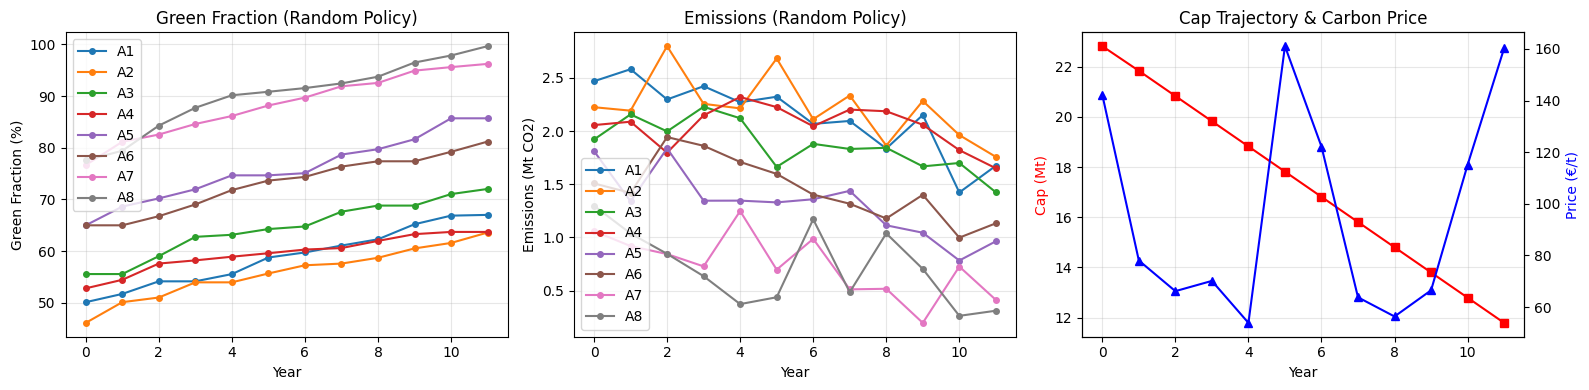

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

ax = axes[0]
for i in range(n_agents):
    ax.plot(df['year'], df[f'green_A{i+1}'] * 100, label=f'A{i+1}', marker='o', ms=4)
ax.set_xlabel('Year'); ax.set_ylabel('Green Fraction (%)')
ax.set_title('Green Fraction (Random Policy)'); ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1]
for i in range(n_agents):
    ax.plot(df['year'], df[f'emissions_A{i+1}'], label=f'A{i+1}', marker='o', ms=4)
ax.set_xlabel('Year'); ax.set_ylabel('Emissions (Mt CO2)')
ax.set_title('Emissions (Random Policy)'); ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[2]
ax.plot(df['year'], df['cap'], label='Cap (Mt)', marker='s', color='red')
ax2 = ax.twinx()
ax2.plot(df['year'], df['price'], label='Price (\u20ac/t)', marker='^', color='blue')
ax.set_xlabel('Year'); ax.set_ylabel('Cap (Mt)', color='red')
ax2.set_ylabel('Price (\u20ac/t)', color='blue')
ax.set_title('Cap Trajectory & Carbon Price'); ax.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

## 5. Train PPO Agents (Short Run)

In [7]:
import copy
from scripts.train import train_one_seed

SKIP_SHORT_RUN = True  # Set to False to run a quick test training (1500 episodes) for debugging/logging verification

train_config = copy.deepcopy(config)
train_config["simulation"]["n_episodes"] = 1500
train_config["logging"]["log_interval"] = 50
train_config["logging"]["save_interval"] = 100
train_config["logging"]["snapshot_interval"] = 500  # save log snapshots every 500 episodes

if not SKIP_SHORT_RUN:
    train_one_seed(train_config, seed=42)


## 6. Quick Results Check

In [8]:
if not SKIP_SHORT_RUN:
    ep_df = pd.read_csv('results/training_log_s42.csv')
    yr_df = pd.read_csv('results/year_log_s42.csv')
    n_agents = config['companies']['n_agents']
    agent_colors = [plt.cm.tab10(i) for i in range(n_agents)]
    ROLL = 50

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    ax = axes[0, 0]
    for i in range(n_agents):
        ax.plot(ep_df['episode'], ep_df[f'reward_A{i+1}'].rolling(ROLL, min_periods=1).mean(),
                color=agent_colors[i], label=f'A{i+1}', lw=0.9)
    ax.set_xlabel('Episode'); ax.set_ylabel('Reward')
    ax.set_title('Per-Agent Reward (rolling mean)'); ax.legend(fontsize=7, ncol=4); ax.grid(True, alpha=0.3)

    ax = axes[0, 1]
    ax.plot(ep_df['episode'], ep_df['clearing_price_last'].rolling(ROLL, min_periods=1).mean(), color='darkblue')
    ax.set_xlabel('Episode'); ax.set_ylabel('Price (\u20ac/t)')
    ax.set_title('Clearing Price (last year, rolling mean)'); ax.grid(True, alpha=0.3)

    ax = axes[1, 0]
    for i in range(n_agents):
        ax.plot(ep_df['episode'], ep_df[f'green_frac_A{i+1}'].rolling(ROLL, min_periods=1).mean(),
                color=agent_colors[i], label=f'A{i+1}', lw=0.9)
    ax.set_xlabel('Episode'); ax.set_ylabel('Green Fraction')
    ax.set_title('Green Fraction (rolling mean)'); ax.legend(fontsize=7, ncol=4); ax.grid(True, alpha=0.3)

    ax = axes[1, 1]
    ax.bar(ep_df['episode'], ep_df['secondary_volume'].rolling(ROLL, min_periods=1).mean(),
        width=max(1, len(ep_df)//200), alpha=0.5, color='steelblue', label='Volume (Mt)')
    ax2 = ax.twinx()
    ax2.plot(ep_df['episode'], ep_df['secondary_match_rate'].rolling(ROLL, min_periods=1).mean(),
            color='coral', lw=1.2, label='Match Rate')
    ax.set_xlabel('Episode'); ax.set_ylabel('Volume (Mt)'); ax2.set_ylabel('Match Rate')
    ax.set_title('Secondary Market'); ax.grid(True, alpha=0.3)
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, fontsize=8)

    plt.suptitle('Quick Results Check', fontsize=14, y=1.01)
    plt.tight_layout(); plt.show()

## 7. Full Training Run

Run for more episodes to allow agents to develop meaningful strategies.
The analysis sections below are designed for this longer run.

In [9]:
import copy
from scripts.train import train_one_seed

SEED=777

full_config = copy.deepcopy(config)
full_config["simulation"]["n_episodes"] = 120000
full_config["logging"]["log_interval"] = 100
full_config["logging"]["results_dir"] = "results/"
full_config["logging"]["snapshot_interval"] = 2500  # save CSV snapshots every 2500 episodes

train_one_seed(full_config, seed=SEED)



ETS MARL — config version 8.5.4
Training — seed 777, 8 learning agents, HAPPO (sequential update, centralized critic), two-phase
Carry-forward:  | Clipped Gaussian | ε-greedy 25%→2%
PPO profile: long-run (threshold>20000 episodes) | lr=0.0002 | entropy_final=0.015 | episodes_per_update=32

════════════════════════════════════════════════════════════════════════════════════════════════════
  TRAINING CONSOLE — FIELD GUIDE
════════════════════════════════════════════════════════════════════════════════════════════════════

  ┌─ CONTROL PLANE
  │  Ep / elapsed / ETA    Episode number · wall-clock time · estimated remaining
  │  ent / shp / ε         Entropy coef · shaping weight · ε-greedy rate
  │  [ENT-DECAY]           Entropy coefficient is being annealed down
  │  [cyc=Ax]              Soft cycling — only agent Ax updates its actor this interval
  │  [WARMUP]              Critic-only warmup phase (actor frozen)

  ┌─ MARKET TRAJECTORY  (one value per simulated year, oldest → newest)


KeyboardInterrupt: 

---
# Post-Training Analysis

> **Run the data-loading cell below first**, then jump to either part.

| Part | Purpose |
|------|---------|
| **Part I — Diagnostic** | Is the *simulation itself* realistic and mechanically correct? |
| **Part II — Analytical** | What *strategies* did the agents learn? |

In [ ]:
# ── Load & Prepare Data (run this first) ─────────────────────────────
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns

def _resolve_results_dir(seed=42):
    train_name = f"training_log_s{seed}.csv"
    year_name = f"year_log_s{seed}.csv"

    candidates = []
    if "RESULTS_DIR" in globals():
        candidates.append(Path(RESULTS_DIR))
    if "PROJECT_ROOT" in globals():
        candidates.append(Path(PROJECT_ROOT) / "results")
    candidates.extend([
        Path("results"),
        Path("../results"),
        Path("ets_marl_happo_current/results"),
        Path("../ets_marl_happo_current/results"),
    ])

    # de-duplicate while preserving order
    seen = set()
    unique_candidates = []
    for d in candidates:
        dr = d.resolve()
        if dr not in seen:
            seen.add(dr)
            unique_candidates.append(dr)

    for d in unique_candidates:
        if (d / train_name).exists() and (d / year_name).exists():
            return d

    searched = "\n".join(str(d) for d in unique_candidates)
    raise FileNotFoundError(
        f"Could not find {train_name} and {year_name}.\n"
        f"Current working directory: {Path.cwd()}\n"
        f"Searched:\n{searched}"
    )


if "SEED" not in globals():
    SEED = 421


results_dir = _resolve_results_dir(SEED)
ep_df = pd.read_csv(results_dir / f"training_log_s{SEED}.csv")
yr_df = pd.read_csv(results_dir / f"year_log_s{SEED}.csv")

if "config" in globals() and "companies" in config:
    n_agents = int(config["companies"]["n_agents"])
else:
    # Fallback if setup cells were not run: infer from reward columns.
    n_agents = len([c for c in ep_df.columns if c.startswith("reward_A")])

sns.set_style("whitegrid")
agent_colors = [plt.cm.tab10(i) for i in range(n_agents)]
_base_archetypes = ["Coal-Heavy", "Gas-Dominant", "Mixed", "Near-Green"]
agent_labels = []
for arch in _base_archetypes:
    for _ in range(n_agents // 4):
        agent_labels.append(f"A{len(agent_labels)+1} ({arch})")
while len(agent_labels) < n_agents:
    agent_labels.append(f"A{len(agent_labels)+1}")

LAST_N = min(200, max(1, len(ep_df) // 4))
last_episodes = ep_df["episode"].unique()[-LAST_N:]
recent_ep = ep_df[ep_df["episode"].isin(last_episodes)].copy()
recent_yr = yr_df[yr_df["episode"].isin(last_episodes)].copy()
ROLL = 50

n_years_per_ep = yr_df.groupby("episode")["year"].count().mode().iloc[0]

print(f"Loaded data from: {results_dir} | Seed: {SEED}")
print(f"Loaded {len(ep_df)} episodes, {len(yr_df)} year-rows")
print(f"Converged window: last {LAST_N} episodes  |  {n_years_per_ep} years/episode")
print(f"Agents: {n_agents}  |  Archetypes: {agent_labels}")

Loaded data from: C:\Users\danie\Documents\Python_Scripts\Master Thesis\Thesis-Energy-Auction\results | Seed: 124
Loaded 10000 episodes, 120000 year-rows
Converged window: last 200 episodes  |  12 years/episode
Agents: 8  |  Archetypes: ['A1 (Coal-Heavy)', 'A2 (Coal-Heavy)', 'A3 (Gas-Dominant)', 'A4 (Gas-Dominant)', 'A5 (Mixed)', 'A6 (Mixed)', 'A7 (Near-Green)', 'A8 (Near-Green)']


---
# Part I — Diagnostic Deep Dive (D)

> *Is the simulation behaving correctly?*
>
> Reordered vs. the original notebook: **D5 (stochastic shocks) is last**, and the dedicated green-investing (D7) and collateral (D9 / D9b) sections are removed. Collateral is folded into the reward-decomposition panel in §A5.

### D1. Training Convergence

Check that neural networks are learning stably:
- Losses decreasing
- Entropy decay triggered at the right time
- Rewards stabilizing

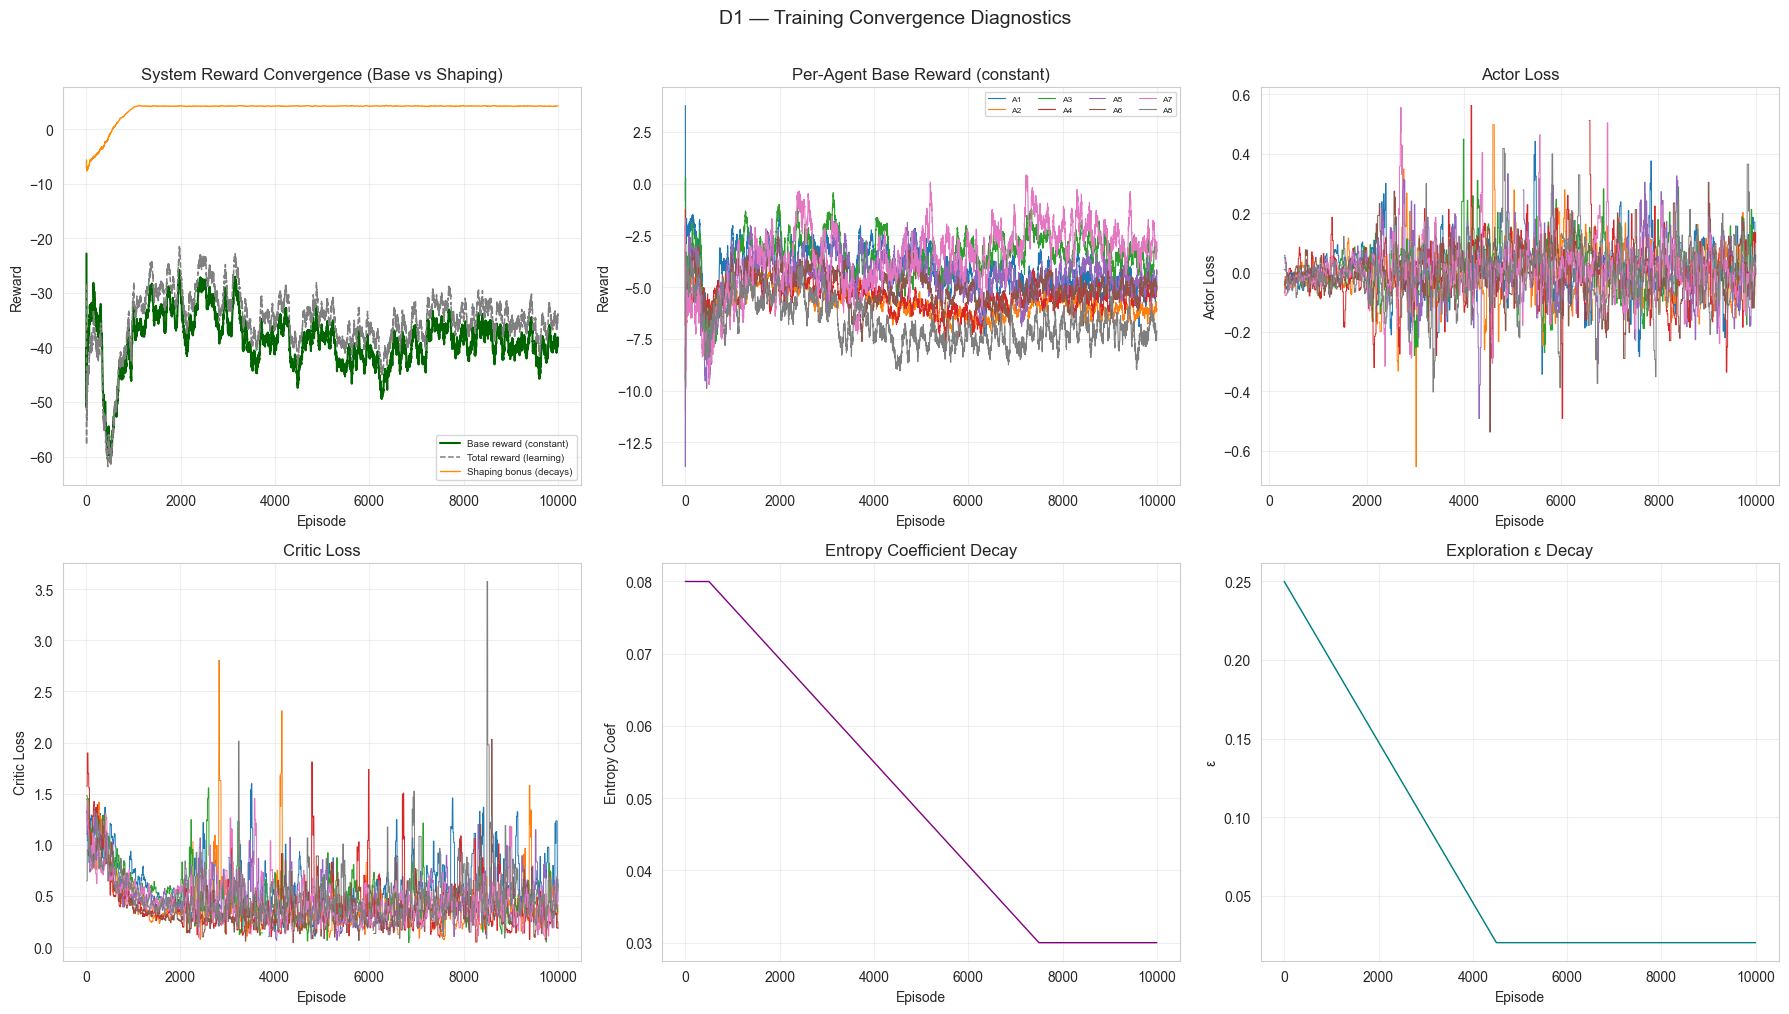

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Support both new (v6.4+) and legacy reward logs
reward_cols_total = [f'reward_A{i+1}' for i in range(n_agents) if f'reward_A{i+1}' in ep_df.columns]
reward_cols_base = [f'reward_base_A{i+1}' for i in range(n_agents) if f'reward_base_A{i+1}' in ep_df.columns]
reward_cols_shaping = [f'reward_shaping_A{i+1}' for i in range(n_agents) if f'reward_shaping_A{i+1}' in ep_df.columns]

# 1 — System reward trajectory
ax = axes[0, 0]
if reward_cols_total:
    total_rew = ep_df[reward_cols_total].sum(axis=1)
    total_roll = total_rew.rolling(ROLL, min_periods=1).mean()

    if reward_cols_base:
        total_base = ep_df[reward_cols_base].sum(axis=1)
        base_roll = total_base.rolling(ROLL, min_periods=1).mean()
        ax.plot(ep_df['episode'], base_roll, color='darkgreen', lw=1.5, label='Base reward (constant)')
        ax.plot(ep_df['episode'], total_roll, color='gray', lw=1.1, ls='--', label='Total reward (learning)')

        if reward_cols_shaping:
            total_shaping = ep_df[reward_cols_shaping].sum(axis=1)
            shape_roll = total_shaping.rolling(ROLL, min_periods=1).mean()
            ax.plot(ep_df['episode'], shape_roll, color='darkorange', lw=1.0, label='Shaping bonus (decays)')
        ax.legend(fontsize=7)
        ax.set_title('System Reward Convergence (Base vs Shaping)')
    else:
        ax.plot(ep_df['episode'], total_roll, color='darkgreen', lw=1.2)
        ax.set_title('System Reward Convergence (Total only)')
else:
    ax.text(0.5, 0.5, 'Reward columns not available', ha='center', va='center', transform=ax.transAxes)
ax.set_xlabel('Episode'); ax.set_ylabel('Reward'); ax.grid(True, alpha=0.3)

# 2 — Per-agent reward (constant trajectory when available)
ax = axes[0, 1]
per_agent_cols = reward_cols_base if reward_cols_base else reward_cols_total
for i in range(n_agents):
    col = f'reward_base_A{i+1}' if reward_cols_base else f'reward_A{i+1}'
    if col in ep_df.columns:
        ax.plot(ep_df['episode'], ep_df[col].rolling(ROLL, min_periods=1).mean(),
                color=agent_colors[i], lw=0.8, label=f'A{i+1}')
ax.set_xlabel('Episode'); ax.set_ylabel('Reward')
if reward_cols_base:
    ax.set_title('Per-Agent Base Reward (constant)')
else:
    ax.set_title('Per-Agent Reward (total)')
ax.legend(fontsize=6, ncol=4); ax.grid(True, alpha=0.3)

# 3 — Actor loss
ax = axes[0, 2]
for i in range(n_agents):
    col = f'actor_loss_A{i+1}'
    if col in ep_df.columns:
        vals = ep_df[col].replace(0, np.nan).rolling(ROLL, min_periods=1).mean()
        ax.plot(ep_df['episode'], vals, color=agent_colors[i], lw=0.7)
ax.set_xlabel('Episode'); ax.set_ylabel('Actor Loss')
ax.set_title('Actor Loss'); ax.grid(True, alpha=0.3)

# 4 — Critic loss
ax = axes[1, 0]
for i in range(n_agents):
    col = f'critic_loss_A{i+1}'
    if col in ep_df.columns:
        vals = ep_df[col].replace(0, np.nan).rolling(ROLL, min_periods=1).mean()
        ax.plot(ep_df['episode'], vals, color=agent_colors[i], lw=0.7)
ax.set_xlabel('Episode'); ax.set_ylabel('Critic Loss')
ax.set_title('Critic Loss'); ax.grid(True, alpha=0.3)

# 5 — Entropy coefficient
ax = axes[1, 1]
ax.plot(ep_df['episode'], ep_df['entropy_coef'], color='purple', lw=1)
ax.set_xlabel('Episode'); ax.set_ylabel('Entropy Coef')
ax.set_title('Entropy Coefficient Decay'); ax.grid(True, alpha=0.3)

# 6 — Epsilon
ax = axes[1, 2]
ax.plot(ep_df['episode'], ep_df['epsilon'], color='teal', lw=1)
ax.set_xlabel('Episode'); ax.set_ylabel('ε')
ax.set_title('Exploration ε Decay'); ax.grid(True, alpha=0.3)

plt.suptitle('D1 — Training Convergence Diagnostics', fontsize=14, y=1.01)
plt.tight_layout(); plt.show()

### D2. Carbon Price & Cap Schedule

The clearing price should broadly reflect real EU ETS dynamics:
- Phase 4 prices in the €50–100 range
- Prices rising as the cap tightens under the LRF
- TNAC declining over time as MSR absorbs surplus

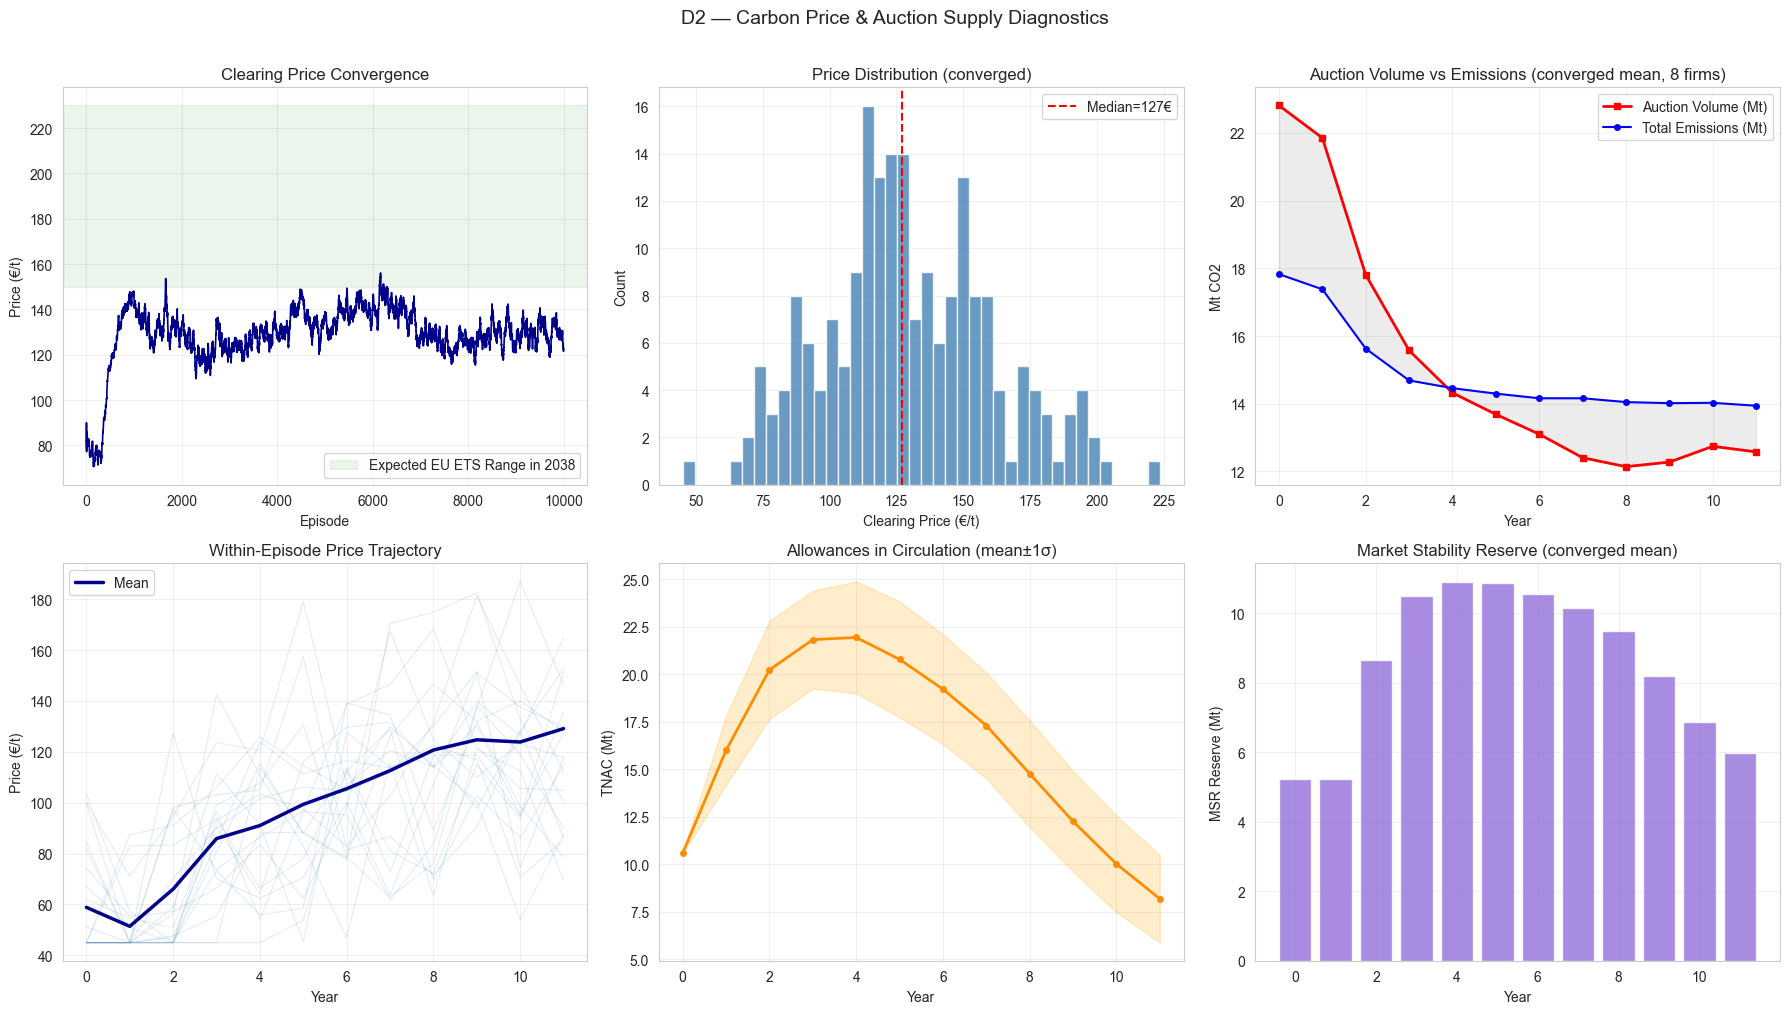

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1 — Clearing price over training
ax = axes[0, 0]
ax.plot(ep_df['episode'], ep_df['clearing_price_last'].rolling(ROLL, min_periods=1).mean(),
    color='darkblue', lw=1.2)
ax.axhspan(150, 230, alpha=0.08, color='green', label='Expected EU ETS Range in 2038')
ax.set_xlabel('Episode'); ax.set_ylabel('Price (€/t)')
ax.set_title('Clearing Price Convergence'); ax.legend(); ax.grid(True, alpha=0.3)

# 2 — Price distribution (converged)
ax = axes[0, 1]
prices_conv = recent_yr.groupby('episode')['clearing_price'].last()
ax.hist(prices_conv, bins=40, color='steelblue', edgecolor='white', alpha=0.8)
ax.axvline(prices_conv.median(), color='red', ls='--', label=f'Median={prices_conv.median():.0f}€')
ax.set_xlabel('Clearing Price (€/t)'); ax.set_ylabel('Count')
ax.set_title('Price Distribution (converged)'); ax.legend(); ax.grid(True, alpha=0.3)

# 3 — Auctioned volume vs total emissions (ALL companies incl. bots)
ax = axes[0, 2]
auction_by_yr = recent_yr.groupby('year')['auction_volume'].mean()

emis_cols = sorted(
    [c for c in recent_yr.columns if c.startswith('emissions_A')],
    key=lambda c: int(c.split('_A')[1])
)
total_emis_by_row = recent_yr[emis_cols].sum(axis=1)
emis_by_yr = total_emis_by_row.groupby(recent_yr['year']).mean()

ax.plot(auction_by_yr.index, auction_by_yr.values, 'r-s', ms=5, label='Auction Volume (Mt)', lw=2)
ax.plot(emis_by_yr.index, emis_by_yr.values, 'b-o', ms=4, label='Total Emissions (Mt)', lw=1.5)
ax.fill_between(auction_by_yr.index, auction_by_yr.values, emis_by_yr.values, alpha=0.15, color='gray')
ax.set_xlabel('Year'); ax.set_ylabel('Mt CO2')
ax.set_title(f'Auction Volume vs Emissions (converged mean, {len(emis_cols)} firms)')
ax.legend(); ax.grid(True, alpha=0.3)

# 4 — Within-episode price trajectory
ax = axes[1, 0]
sample_eps = sorted(recent_yr['episode'].unique()[-20:])
for ep in sample_eps:
    ep_data = recent_yr[recent_yr['episode'] == ep]
    ax.plot(ep_data['year'], ep_data['clearing_price'], color='steelblue', alpha=0.15, lw=0.8)
mean_price_yr = recent_yr.groupby('year')['clearing_price'].mean()
ax.plot(mean_price_yr.index, mean_price_yr.values, 'darkblue', lw=2.5, label='Mean')
ax.set_xlabel('Year'); ax.set_ylabel('Price (€/t)')
ax.set_title('Within-Episode Price Trajectory'); ax.legend(); ax.grid(True, alpha=0.3)

# 5 — TNAC over years
ax = axes[1, 1]
tnac_yr = recent_yr.groupby('year')['tnac'].agg(['mean', 'std'])
std_tnac = tnac_yr['std'].fillna(0.0)
ax.plot(tnac_yr.index, tnac_yr['mean'], 'darkorange', lw=2, marker='o', ms=4)
ax.fill_between(tnac_yr.index, tnac_yr['mean'] - std_tnac, tnac_yr['mean'] + std_tnac,
        alpha=0.2, color='orange')
ax.set_xlabel('Year'); ax.set_ylabel('TNAC (Mt)')
ax.set_title('Allowances in Circulation (mean±1σ)'); ax.grid(True, alpha=0.3)

# 6 — MSR reserve
ax = axes[1, 2]
msr_yr = recent_yr.groupby('year')['msr_reserve'].mean()
ax.bar(msr_yr.index, msr_yr.values, color='mediumpurple', alpha=0.8)
ax.set_xlabel('Year'); ax.set_ylabel('MSR Reserve (Mt)')
ax.set_title('Market Stability Reserve (converged mean)'); ax.grid(True, alpha=0.3)

plt.suptitle('D2 — Carbon Price & Auction Supply Diagnostics', fontsize=14, y=1.01)
plt.tight_layout(); plt.show()

### D3. Auction Mechanics

Sanity checks for the uniform-price auction:
- Allocations should sum to roughly the auctioned volume
- Bid prices should bracket the clearing price
- No persistent auction failures

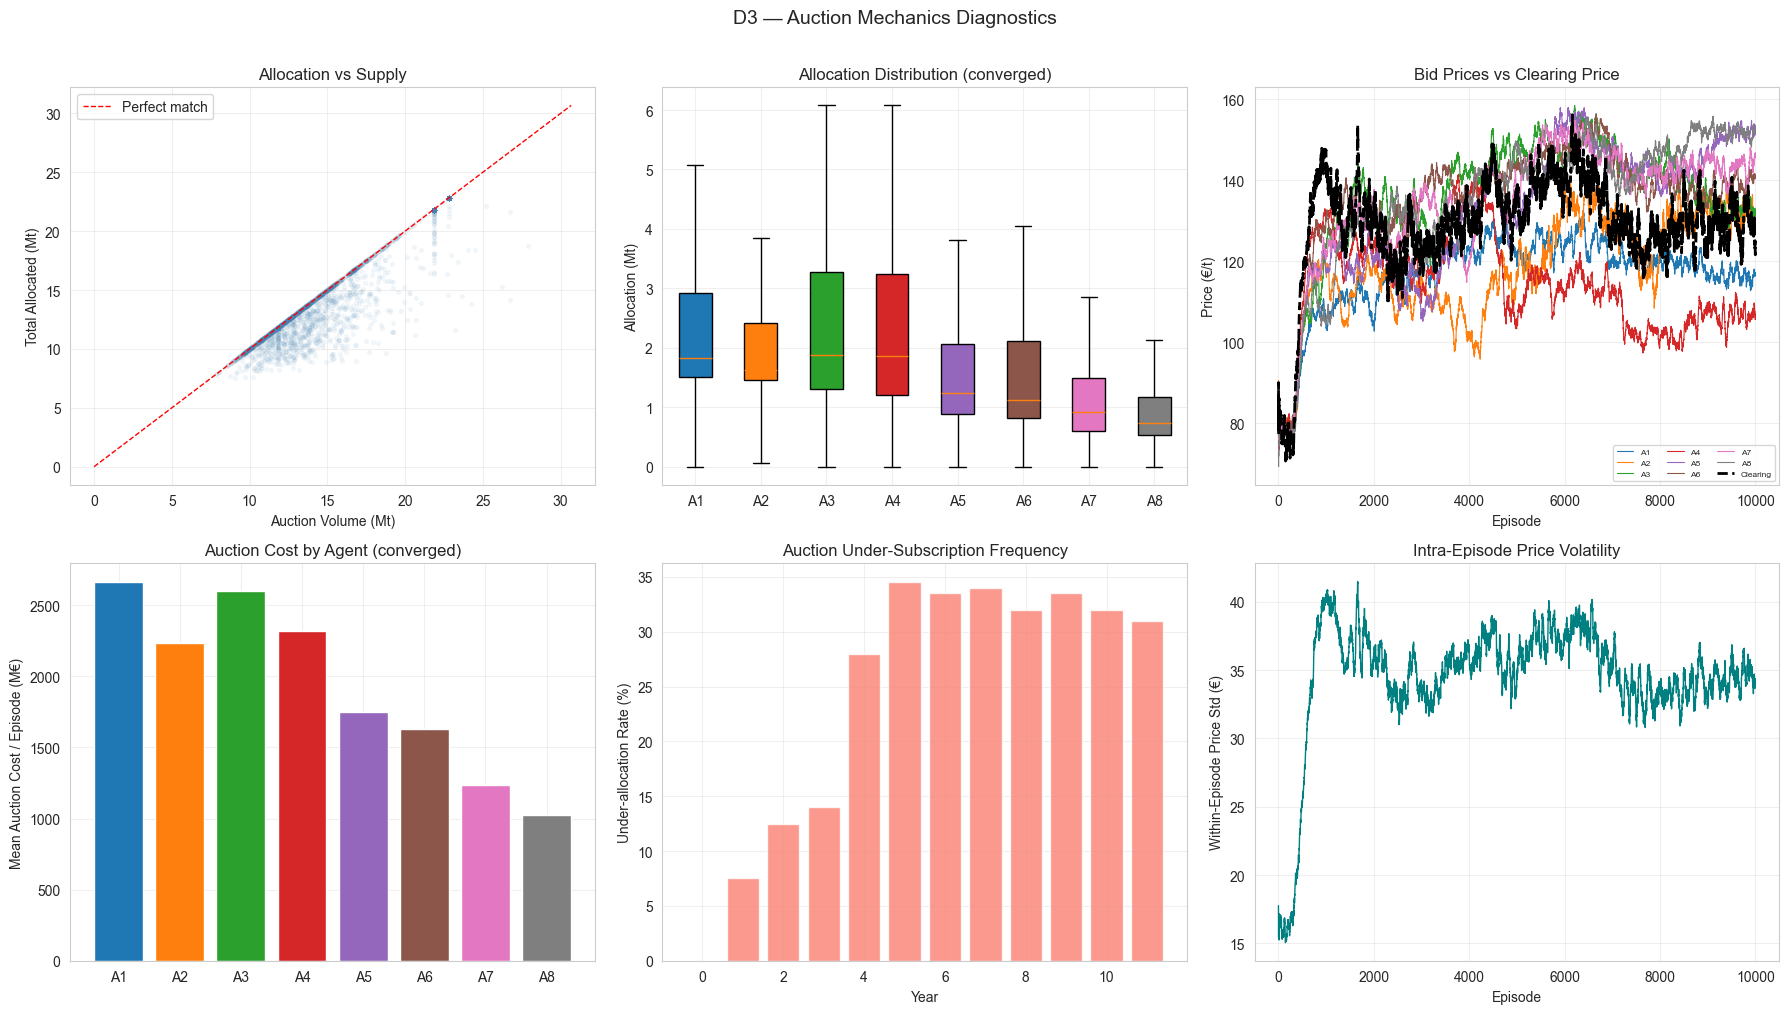

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1 — Total allocation vs auction volume
ax = axes[0, 0]
alloc_cols = [f'alloc_A{i+1}' for i in range(n_agents)]
alloc_total = recent_yr[alloc_cols].sum(axis=1)
ax.scatter(recent_yr['auction_volume'], alloc_total, alpha=0.05, s=8, color='steelblue')
lims = [0, max(recent_yr['auction_volume'].max(), alloc_total.max()) * 1.1]
ax.plot(lims, lims, 'r--', lw=1, label='Perfect match')
ax.set_xlabel('Auction Volume (Mt)'); ax.set_ylabel('Total Allocated (Mt)')
ax.set_title('Allocation vs Supply'); ax.legend(); ax.grid(True, alpha=0.3)

# 2 — Per-agent allocation distribution
ax = axes[0, 1]
alloc_data = [recent_yr[f'alloc_A{i+1}'].values for i in range(n_agents)]
bp = ax.boxplot(alloc_data, tick_labels=[f'A{i+1}' for i in range(n_agents)],
                patch_artist=True, showfliers=False)
for i, patch in enumerate(bp['boxes']):
    patch.set_facecolor(agent_colors[i])
ax.set_ylabel('Allocation (Mt)'); ax.set_title('Allocation Distribution (converged)')
ax.grid(True, alpha=0.3)

# 3 — Bid price vs clearing price
ax = axes[0, 2]
for i in range(n_agents):
    bid_roll = ep_df[f'bid_price_A{i+1}'].rolling(ROLL, min_periods=1).mean()
    ax.plot(ep_df['episode'], bid_roll, color=agent_colors[i], lw=0.8, label=f'A{i+1}')
clr_roll = ep_df['clearing_price_last'].rolling(ROLL, min_periods=1).mean()
ax.plot(ep_df['episode'], clr_roll, 'k--', lw=2, label='Clearing')
ax.set_xlabel('Episode'); ax.set_ylabel('Price (\u20ac/t)')
ax.set_title('Bid Prices vs Clearing Price'); ax.legend(fontsize=6, ncol=3); ax.grid(True, alpha=0.3)

# 4 — Auction cost per agent (converged)
ax = axes[1, 0]
acost_means = [recent_yr.groupby('episode')[f'auction_cost_A{i+1}'].sum().mean() for i in range(n_agents)]
bars = ax.bar([f'A{i+1}' for i in range(n_agents)], acost_means,
              color=agent_colors)
ax.set_ylabel('Mean Auction Cost / Episode (M\u20ac)')
ax.set_title('Auction Cost by Agent (converged)'); ax.grid(True, alpha=0.3)

# 5 — Under-allocation frequency
ax = axes[1, 1]
# Check how often total allocation < 90% of auction volume
under = alloc_total < 0.9 * recent_yr['auction_volume']
under_rate_yr = under.groupby(recent_yr['year']).mean()
ax.bar(under_rate_yr.index, under_rate_yr.values * 100, color='salmon', alpha=0.8)
ax.set_xlabel('Year'); ax.set_ylabel('Under-allocation Rate (%)')
ax.set_title('Auction Under-Subscription Frequency'); ax.grid(True, alpha=0.3)

# 6 — Price volatility over training
ax = axes[1, 2]
ax.plot(ep_df['episode'], ep_df['price_std'].rolling(ROLL, min_periods=1).mean(),
        color='teal', lw=1)
ax.set_xlabel('Episode'); ax.set_ylabel('Within-Episode Price Std (\u20ac)')
ax.set_title('Intra-Episode Price Volatility'); ax.grid(True, alpha=0.3)

plt.suptitle('D3 \u2014 Auction Mechanics Diagnostics', fontsize=14, y=1.01)
plt.tight_layout(); plt.show()

### D4. Secondary Market Mechanics

Does the double-auction secondary market function properly?
- Reasonable match rates (not all-or-nothing)
- Secondary prices tracking auction prices
- Both buyers and sellers participating

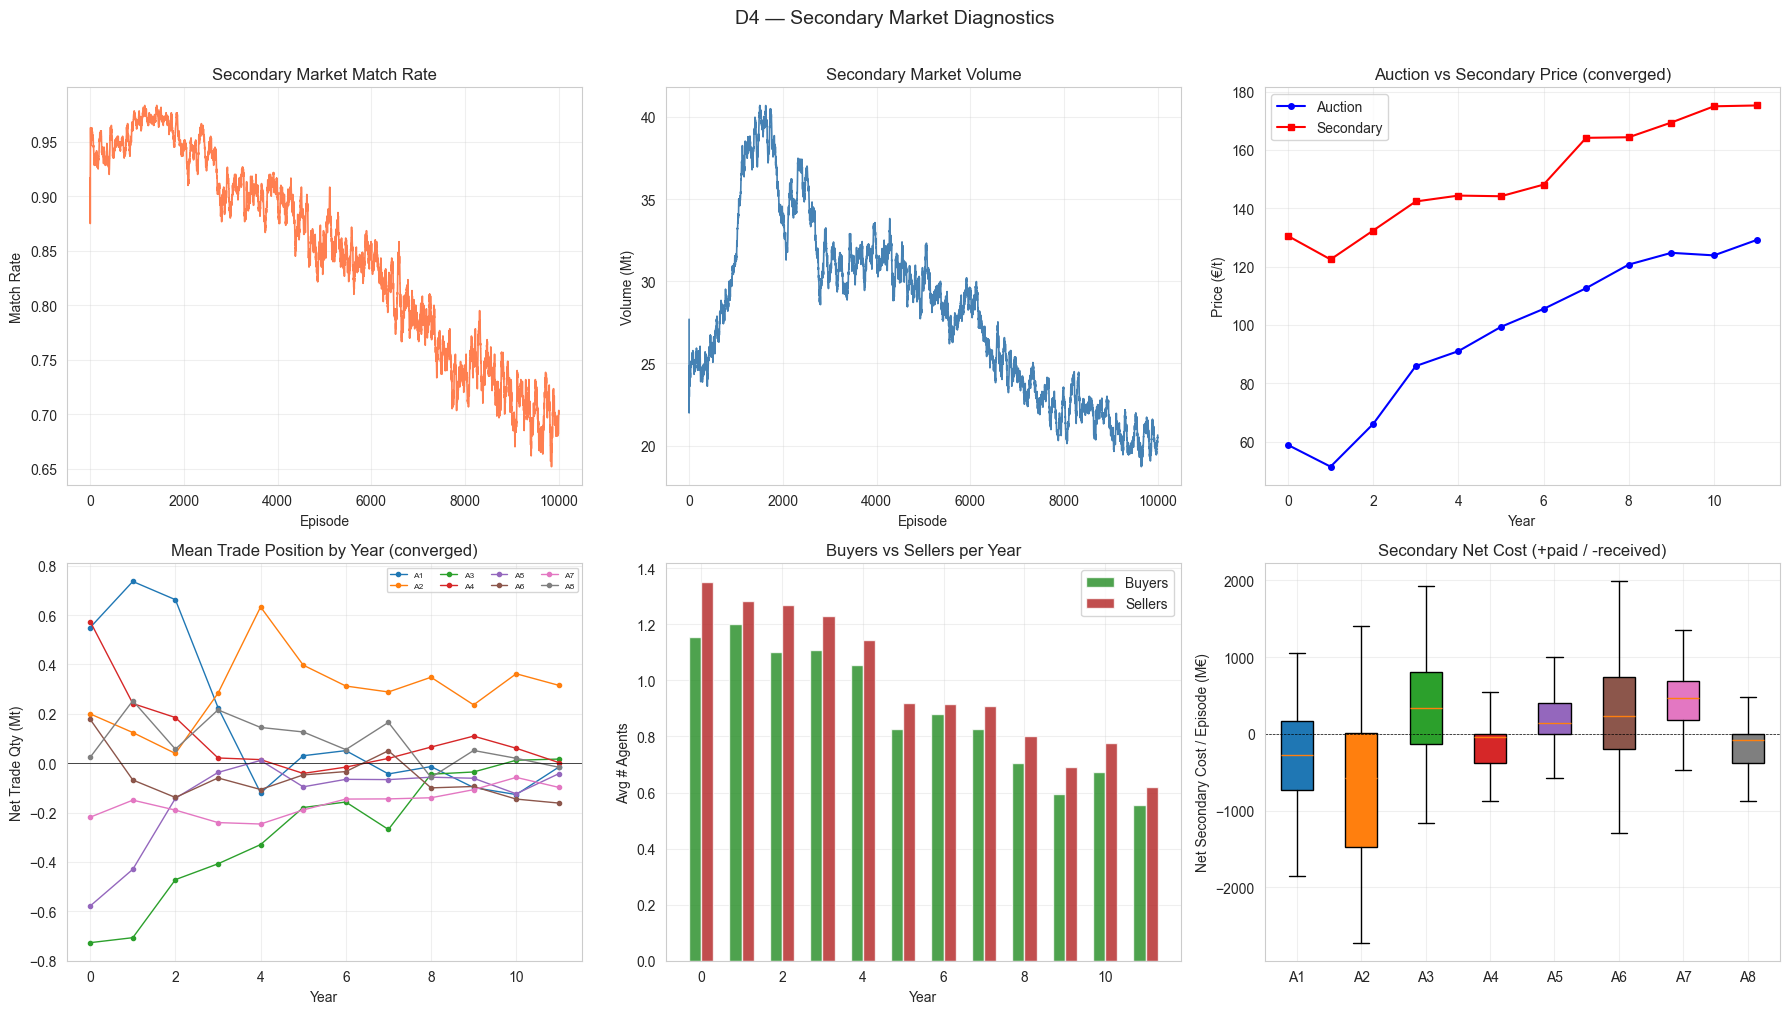

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1 — Match rate over training
ax = axes[0, 0]
ax.plot(ep_df['episode'], ep_df['secondary_match_rate'].rolling(ROLL, min_periods=1).mean(),
        color='coral', lw=1.2)
ax.set_xlabel('Episode'); ax.set_ylabel('Match Rate')
ax.set_title('Secondary Market Match Rate'); ax.grid(True, alpha=0.3)

# 2 — Secondary volume over training
ax = axes[0, 1]
ax.plot(ep_df['episode'], ep_df['secondary_volume'].rolling(ROLL, min_periods=1).mean(),
        color='steelblue', lw=1.2)
ax.set_xlabel('Episode'); ax.set_ylabel('Volume (Mt)')
ax.set_title('Secondary Market Volume'); ax.grid(True, alpha=0.3)

# 3 — Secondary vs Auction price
ax = axes[0, 2]
sec_mean_yr = recent_yr.groupby('year')['secondary_price'].mean()
auc_mean_yr = recent_yr.groupby('year')['clearing_price'].mean()
ax.plot(auc_mean_yr.index, auc_mean_yr.values, 'b-o', ms=4, label='Auction', lw=1.5)
ax.plot(sec_mean_yr.index, sec_mean_yr.values, 'r-s', ms=4, label='Secondary', lw=1.5)
ax.set_xlabel('Year'); ax.set_ylabel('Price (\u20ac/t)')
ax.set_title('Auction vs Secondary Price (converged)'); ax.legend(); ax.grid(True, alpha=0.3)

# 4 — Net trade by agent by year (who buys/sells)
ax = axes[1, 0]
for i in range(n_agents):
    trade_by_yr = recent_yr.groupby('year')[f'trade_qty_A{i+1}'].mean()
    ax.plot(trade_by_yr.index, trade_by_yr.values, color=agent_colors[i],
            marker='o', ms=3, label=f'A{i+1}', lw=1)
ax.axhline(0, color='black', ls='-', lw=0.5)
ax.set_xlabel('Year'); ax.set_ylabel('Net Trade Qty (Mt)')
ax.set_title('Mean Trade Position by Year (converged)')
ax.legend(fontsize=6, ncol=4); ax.grid(True, alpha=0.3)

# 5 — Buy/sell balance: count of buyers vs sellers per year
ax = axes[1, 1]
buy_count_yr = []
sell_count_yr = []
for yr in range(n_years_per_ep):
    yr_data = recent_yr[recent_yr['year'] == yr]
    n_buy = sum((yr_data[f'trade_qty_A{i+1}'] > 0.01).mean() for i in range(n_agents))
    n_sell = sum((yr_data[f'trade_qty_A{i+1}'] < -0.01).mean() for i in range(n_agents))
    buy_count_yr.append(n_buy)
    sell_count_yr.append(n_sell)
x = np.arange(n_years_per_ep)
ax.bar(x - 0.15, buy_count_yr, 0.3, color='forestgreen', alpha=0.8, label='Buyers')
ax.bar(x + 0.15, sell_count_yr, 0.3, color='firebrick', alpha=0.8, label='Sellers')
ax.set_xlabel('Year'); ax.set_ylabel('Avg # Agents')
ax.set_title('Buyers vs Sellers per Year'); ax.legend(); ax.grid(True, alpha=0.3)

# 6 — Secondary net cost distribution
ax = axes[1, 2]
snet_data = []
for i in range(n_agents):
    ep_snet = recent_yr.groupby('episode')[f'secondary_net_A{i+1}'].sum()
    snet_data.append(ep_snet.values)
bp = ax.boxplot(snet_data, tick_labels=[f'A{i+1}' for i in range(n_agents)],
                patch_artist=True, showfliers=False)
for i, patch in enumerate(bp['boxes']):
    patch.set_facecolor(agent_colors[i])
ax.axhline(0, color='black', ls='--', lw=0.5)
ax.set_ylabel('Net Secondary Cost / Episode (M\u20ac)')
ax.set_title('Secondary Net Cost (+paid / -received)')
ax.grid(True, alpha=0.3)

plt.suptitle('D4 \u2014 Secondary Market Diagnostics', fontsize=14, y=1.01)
plt.tight_layout(); plt.show()

### D6. Compliance & Penalty Mechanics

Verify that compliance mechanics work:
- Shortfalls are detected and penalized
- Penalties are proportional to shortfall
- Banking (carry-over) functions correctly

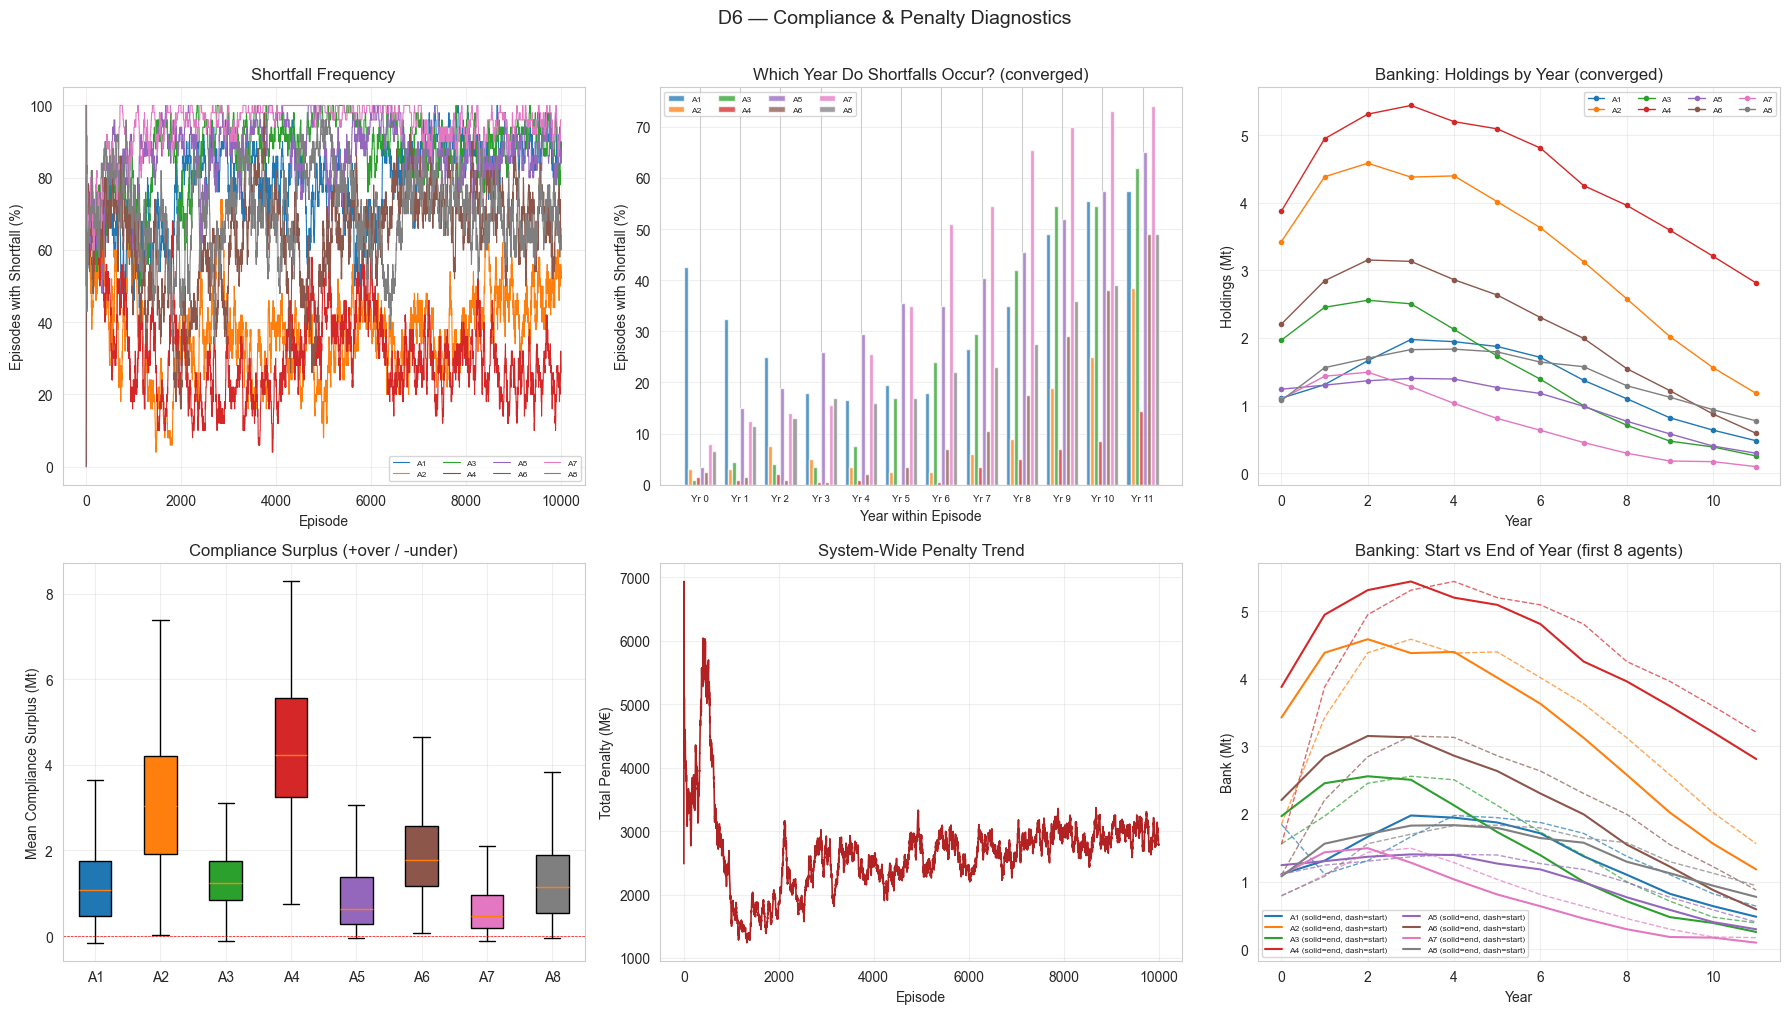

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1 — Shortfall rate over training
ax = axes[0, 0]
for i in range(n_agents):
    sf = (ep_df[f'shortfall_A{i+1}'] > 1e-6).astype(float).rolling(ROLL, min_periods=1).mean()
    ax.plot(ep_df['episode'], sf * 100, color=agent_colors[i], lw=0.8, label=f'A{i+1}')
ax.set_xlabel('Episode'); ax.set_ylabel('Episodes with Shortfall (%)')
ax.set_title('Shortfall Frequency'); ax.legend(fontsize=6, ncol=4); ax.grid(True, alpha=0.3)

# 2 - Which year do shortfalls occur? (converged episodes)
ax = axes[0, 1]
shortfall_by_year = {}
for yr in sorted(recent_yr['year'].unique()):
    yr_rows = recent_yr[recent_yr['year'] == yr]
    rates = [(yr_rows[f'shortfall_A{i+1}'] > 1e-6).mean() for i in range(n_agents)]
    shortfall_by_year[yr] = rates
years = sorted(shortfall_by_year.keys())
x = np.arange(len(years))
bar_w = 0.8 / max(n_agents, 1)
for i in range(n_agents):
    vals = [shortfall_by_year[yr][i] * 100 for yr in years]
    ax.bar(x + i * bar_w - 0.4 + bar_w/2, vals, width=bar_w,
           color=agent_colors[i], alpha=0.75, label=f'A{i+1}')
ax.set_xticks(x); ax.set_xticklabels([f'Yr {y}' for y in years], fontsize=7)
ax.set_xlabel('Year within Episode'); ax.set_ylabel('Episodes with Shortfall (%)')
ax.set_title('Which Year Do Shortfalls Occur? (converged)')
ax.legend(fontsize=6, ncol=4); ax.grid(True, alpha=0.3, axis='y')

# 3 — Holdings by year (banking)
ax = axes[0, 2]
for i in range(n_agents):
    hold_yr = recent_yr.groupby('year')[f'holdings_A{i+1}'].mean()
    ax.plot(hold_yr.index, hold_yr.values, color=agent_colors[i], marker='o', ms=3,
            label=f'A{i+1}', lw=1)
ax.set_xlabel('Year'); ax.set_ylabel('Holdings (Mt)')
ax.set_title('Banking: Holdings by Year (converged)')
ax.legend(fontsize=6, ncol=4); ax.grid(True, alpha=0.3)

# 4 — Compliance surplus distribution
ax = axes[1, 0]
if f'compliance_surplus_A1' in recent_yr.columns:
    surp_data = [recent_yr.groupby('episode')[f'compliance_surplus_A{i+1}'].mean().values
                 for i in range(n_agents)]
    bp = ax.boxplot(surp_data, tick_labels=[f'A{i+1}' for i in range(n_agents)],
                    patch_artist=True, showfliers=False)
    for i, patch in enumerate(bp['boxes']):
        patch.set_facecolor(agent_colors[i])
    ax.axhline(0, color='red', ls='--', lw=0.5)
    ax.set_ylabel('Mean Compliance Surplus (Mt)')
    ax.set_title('Compliance Surplus (+over / -under)')
else:
    ax.text(0.5, 0.5, 'compliance_surplus not logged', ha='center', va='center',
            transform=ax.transAxes)
ax.grid(True, alpha=0.3)

# 5 — Total penalty over training
ax = axes[1, 1]
pen_cols = [f'penalty_A{i+1}' for i in range(n_agents)]
total_pen = ep_df[pen_cols].sum(axis=1)
ax.plot(ep_df['episode'], total_pen.rolling(ROLL, min_periods=1).mean(), color='firebrick', lw=1.2)
ax.set_xlabel('Episode'); ax.set_ylabel('Total Penalty (M€)')
ax.set_title('System-Wide Penalty Trend'); ax.grid(True, alpha=0.3)

# 6 — Carry-forward: bank_end vs bank_start
ax = axes[1, 2]
if 'bank_end_A1' in recent_yr.columns and 'bank_start_A1' in recent_yr.columns:
    for i in range(min(8, n_agents)):
        bs = recent_yr.groupby('year')[f'bank_start_A{i+1}'].mean()
        be = recent_yr.groupby('year')[f'bank_end_A{i+1}'].mean()
        ax.plot(bs.index, bs.values, color=agent_colors[i], ls='--', lw=1, alpha=0.7)
        ax.plot(be.index, be.values, color=agent_colors[i], ls='-', lw=1.5,
                label=f'A{i+1} (solid=end, dash=start)')
    ax.set_xlabel('Year'); ax.set_ylabel('Bank (Mt)')
    ax.set_title('Banking: Start vs End of Year (first 8 agents)')
    ax.legend(fontsize=6, ncol=2)
else:
    ax.text(0.5, 0.5, 'bank_end not logged', ha='center', va='center', transform=ax.transAxes)
ax.grid(True, alpha=0.3)

plt.suptitle('D6 — Compliance & Penalty Diagnostics', fontsize=14, y=1.01)
plt.tight_layout(); plt.show()

### D8. Final-Year Invested Assets, Queue State, and Liquidation Payoff

> This cell now prioritizes liquidation values logged directly from the environment reward computation into year_log CSV.

> Fallback behavior:
> - If `terminal_*_value_A*` columns are absent (older logs), bank liquidation is reconstructed from bank_end × clearing_price / 1000.
> - Queue liquidation is shown only if logged columns exist.

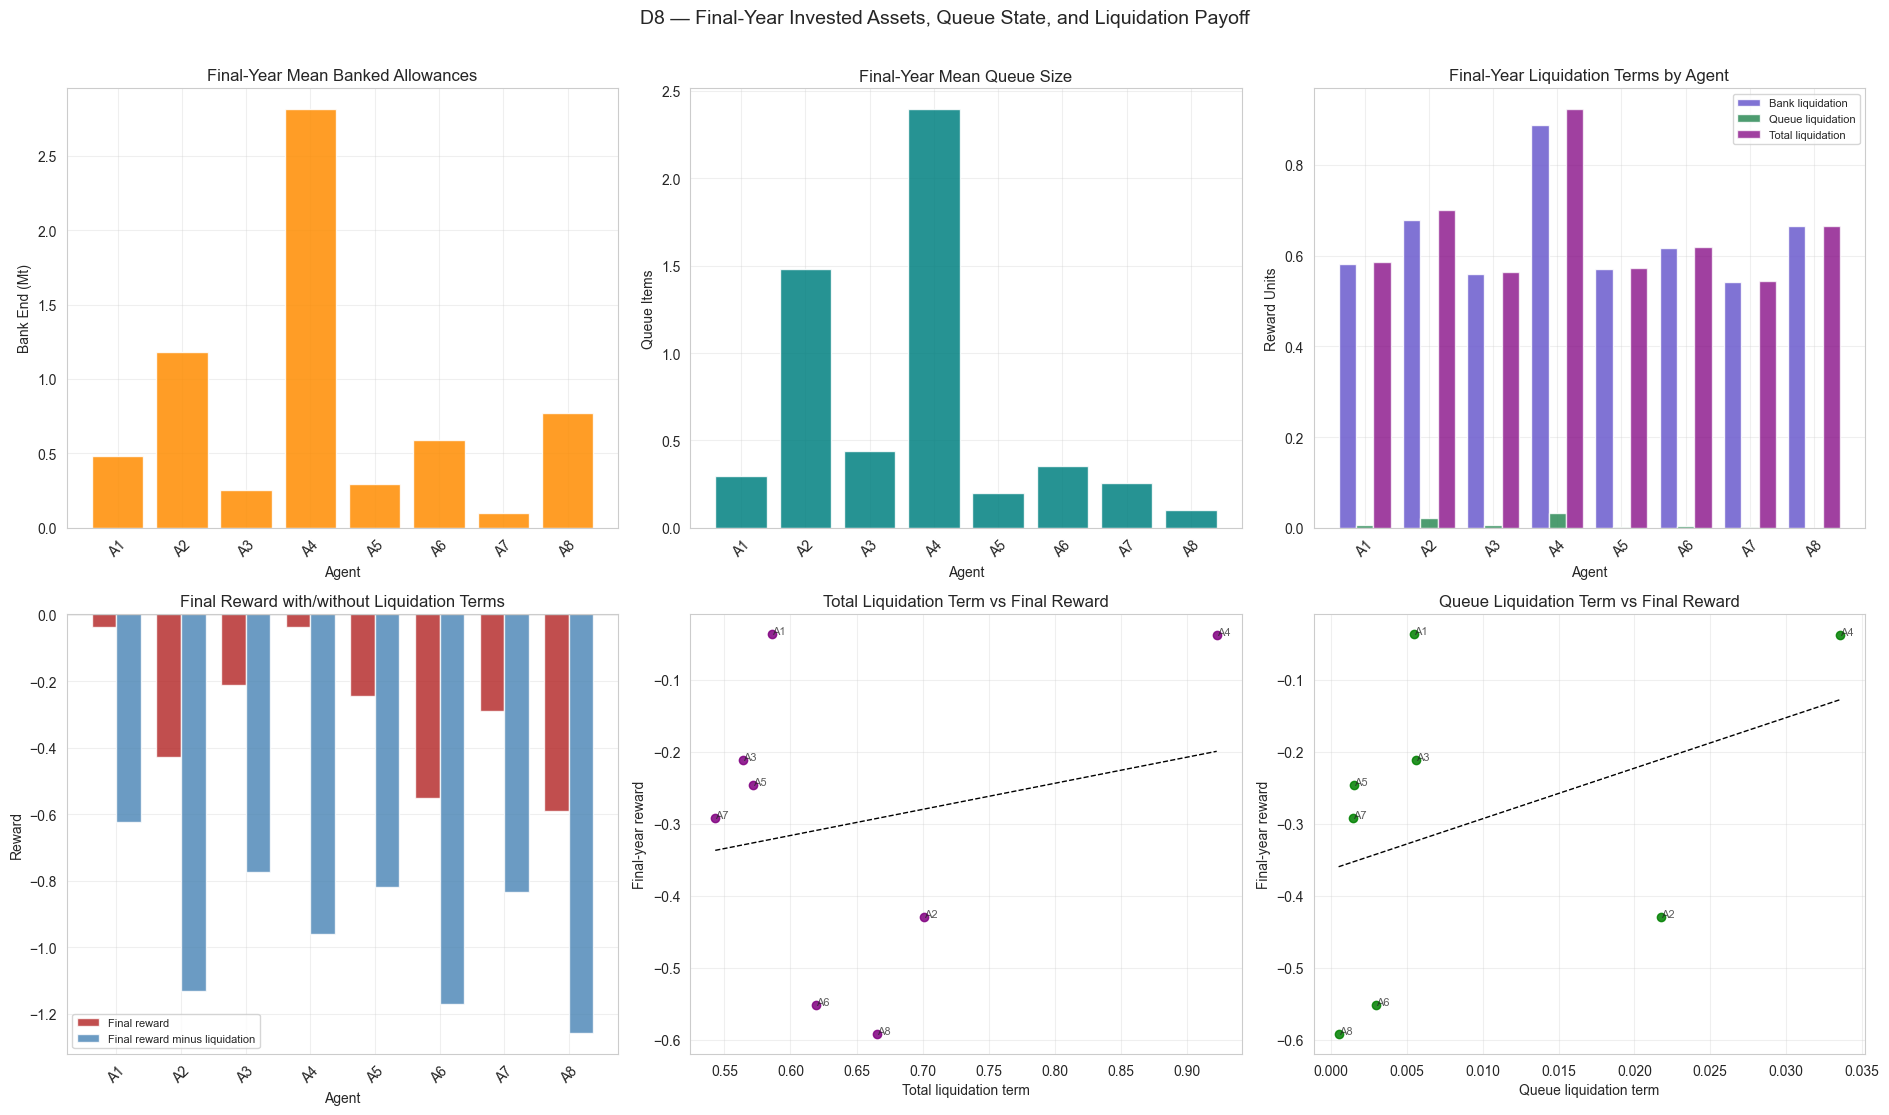

D8 SUMMARY — FINAL-YEAR INVESTED ASSETS, QUEUE STATE, AND LIQUIDATION PAYOFF
terminal_bank_value enabled (config): True
terminal_queue_value enabled (config): True
terminal_payoff_years: 5, gamma: 0.99
Liquidation source: logged terminal_*_value columns
Final-year system reward: -2.39
Pre-final mean system reward: -2.96
Final-year payoff uplift: +0.57
Final-year total bank_end (mean over episodes): 6.48 Mt
Final-year total queue size (mean over episodes): 5.52
Final-year total investment cost (mean over episodes): 123.86 M€
Final-year total liquidation term (mean over episodes): 5.173
 - Bank component: 5.100
 - Queue component: 0.073


In [ ]:
# ── D8: Final-Year Invested Assets, Queue State, and Liquidation Payoff ─────
reward_cols_all = sorted(
    [c for c in recent_yr.columns if c.startswith('reward_A')],
    key=lambda x: int(x.split('_A')[1])
)
n_logged = max(int(c.split('_A')[1]) for c in reward_cols_all) if reward_cols_all else n_agents
agent_ids_logged = list(range(1, n_logged + 1))

reward_cols = [f'reward_A{i}' for i in agent_ids_logged if f'reward_A{i}' in recent_yr.columns]
invest_cols = [f'invest_cost_A{i}' for i in agent_ids_logged if f'invest_cost_A{i}' in recent_yr.columns]
bank_cols = [f'bank_end_A{i}' for i in agent_ids_logged if f'bank_end_A{i}' in recent_yr.columns]
queue_cols = [f'queue_size_A{i}' for i in agent_ids_logged if f'queue_size_A{i}' in recent_yr.columns]

# Resolve config robustly so this cell works even if earlier config-loading cells were not run.
config_obj = None
if isinstance(globals().get('config', None), dict):
    config_obj = globals()['config']
elif isinstance(globals().get('cfg', None), dict):
    config_obj = globals()['cfg']
else:
    try:
        from pathlib import Path
        import yaml

        cfg_path = globals().get('CONFIG_PATH', None)
        if cfg_path is not None and Path(cfg_path).exists():
            with open(cfg_path, 'r', encoding='utf-8') as f:
                loaded_cfg = yaml.safe_load(f) or {}
            if isinstance(loaded_cfg, dict):
                config_obj = loaded_cfg
    except Exception:
        config_obj = None

if config_obj is None:
    config_obj = {}

reward_cfg = config_obj.get('reward', {})
terminal_bank_enabled = bool(reward_cfg.get('terminal_bank_value', False))
terminal_queue_enabled = bool(reward_cfg.get('terminal_queue_value', False))
terminal_payoff_years = reward_cfg.get('terminal_payoff_years', 5)
gamma_discount = config_obj.get('ppo', {}).get('gamma', 0.99)

y_last = int(recent_yr['year'].max())
final_slice = recent_yr[recent_yr['year'] == y_last].copy()

# Logged liquidation columns (new schema)
bank_liq_cols = [f'terminal_bank_value_A{i}' for i in agent_ids_logged if f'terminal_bank_value_A{i}' in final_slice.columns]
queue_liq_cols = [f'terminal_queue_value_A{i}' for i in agent_ids_logged if f'terminal_queue_value_A{i}' in final_slice.columns]
total_liq_cols = [f'terminal_liquidation_value_A{i}' for i in agent_ids_logged if f'terminal_liquidation_value_A{i}' in final_slice.columns]

has_logged_liq = len(total_liq_cols) > 0 or (len(bank_liq_cols) > 0 and len(queue_liq_cols) > 0)

agent_labels = []
final_reward_vals = []
bank_end_vals = []
queue_end_vals = []
bank_liq_vals = []
queue_liq_vals = []
total_liq_vals = []

for i in agent_ids_logged:
    a = f'A{i}'
    r_col = f'reward_A{i}'
    b_col = f'bank_end_A{i}'
    q_col = f'queue_size_A{i}'
    b_liq_col = f'terminal_bank_value_A{i}'
    q_liq_col = f'terminal_queue_value_A{i}'
    t_liq_col = f'terminal_liquidation_value_A{i}'

    if r_col not in final_slice.columns:
        continue

    rf = final_slice[r_col].mean()
    be = final_slice[b_col].mean() if b_col in final_slice.columns else np.nan
    qe = final_slice[q_col].mean() if q_col in final_slice.columns else np.nan

    # Prefer directly logged liquidation terms (auto-tracks formula changes).
    if t_liq_col in final_slice.columns:
        t_liq = final_slice[t_liq_col].mean()
        b_liq = final_slice[b_liq_col].mean() if b_liq_col in final_slice.columns else np.nan
        q_liq = final_slice[q_liq_col].mean() if q_liq_col in final_slice.columns else np.nan
    else:
        # Fallback for old logs: only bank term can be reconstructed exactly.
        if terminal_bank_enabled and b_col in final_slice.columns and 'clearing_price' in final_slice.columns:
            b_liq = (final_slice[b_col] * final_slice['clearing_price'] / 1000.0).mean()
        else:
            b_liq = 0.0
        q_liq = 0.0
        t_liq = b_liq + q_liq

    agent_labels.append(a)
    final_reward_vals.append(rf)
    bank_end_vals.append(be)
    queue_end_vals.append(qe)
    bank_liq_vals.append(b_liq)
    queue_liq_vals.append(q_liq)
    total_liq_vals.append(t_liq)

fig, axes = plt.subplots(2, 3, figsize=(19, 11))

# 1) Final-year banked allowances by agent
ax = axes[0, 0]
if len(bank_end_vals) > 0:
    x = np.arange(len(agent_labels))
    ax.bar(x, bank_end_vals, color='darkorange', alpha=0.85)
    ax.set_xticks(x); ax.set_xticklabels(agent_labels, rotation=45)
    ax.set_title('Final-Year Mean Banked Allowances')
else:
    ax.text(0.5, 0.5, 'bank_end columns not available', ha='center', va='center', transform=ax.transAxes)
ax.set_xlabel('Agent'); ax.set_ylabel('Bank End (Mt)'); ax.grid(True, alpha=0.3)

# 2) Final-year queue size by agent (end-of-simulation queue look)
ax = axes[0, 1]
if len(queue_end_vals) > 0:
    x = np.arange(len(agent_labels))
    ax.bar(x, queue_end_vals, color='teal', alpha=0.85)
    ax.set_xticks(x); ax.set_xticklabels(agent_labels, rotation=45)
    ax.set_title('Final-Year Mean Queue Size')
else:
    ax.text(0.5, 0.5, 'queue_size columns not available', ha='center', va='center', transform=ax.transAxes)
ax.set_xlabel('Agent'); ax.set_ylabel('Queue Items'); ax.grid(True, alpha=0.3)

# 3) Liquidation decomposition (bank / queue / total)
ax = axes[0, 2]
if len(total_liq_vals) > 0:
    x = np.arange(len(agent_labels))
    w = 0.27
    ax.bar(x - w, bank_liq_vals, w, color='slateblue', alpha=0.85, label='Bank liquidation')
    ax.bar(x, queue_liq_vals, w, color='seagreen', alpha=0.85, label='Queue liquidation')
    ax.bar(x + w, total_liq_vals, w, color='purple', alpha=0.75, label='Total liquidation')
    ax.set_xticks(x); ax.set_xticklabels(agent_labels, rotation=45)
    ax.set_title('Final-Year Liquidation Terms by Agent')
    ax.legend(fontsize=8)
else:
    ax.text(0.5, 0.5, 'No liquidation values available', ha='center', va='center', transform=ax.transAxes)
ax.set_xlabel('Agent'); ax.set_ylabel('Reward Units'); ax.grid(True, alpha=0.3)

# 4) Final reward with/without total liquidation
ax = axes[1, 0]
if len(final_reward_vals) > 0:
    rew_minus_liq = [r - l for r, l in zip(final_reward_vals, total_liq_vals)]
    x = np.arange(len(agent_labels))
    w = 0.38
    ax.bar(x - w / 2, final_reward_vals, w, color='firebrick', alpha=0.8, label='Final reward')
    ax.bar(x + w / 2, rew_minus_liq, w, color='steelblue', alpha=0.8, label='Final reward minus liquidation')
    ax.axhline(0, color='black', lw=0.8)
    ax.set_xticks(x); ax.set_xticklabels(agent_labels, rotation=45)
    ax.set_title('Final Reward with/without Liquidation Terms')
    ax.legend(fontsize=8)
else:
    ax.text(0.5, 0.5, 'reward columns not available', ha='center', va='center', transform=ax.transAxes)
ax.set_xlabel('Agent'); ax.set_ylabel('Reward'); ax.grid(True, alpha=0.3)

# 5) Total liquidation term vs final reward
ax = axes[1, 1]
if len(total_liq_vals) > 0 and len(final_reward_vals) > 0:
    tmp = pd.DataFrame({
        'agent': agent_labels,
        'total_liquidation': total_liq_vals,
        'final_reward': final_reward_vals,
    })
    ax.scatter(tmp['total_liquidation'], tmp['final_reward'], s=36, color='purple', alpha=0.85)
    for _, r in tmp.iterrows():
        ax.text(r['total_liquidation'], r['final_reward'], r['agent'], fontsize=8, alpha=0.75)
    if len(tmp) > 2 and tmp['total_liquidation'].std() > 1e-12:
        m = np.polyfit(tmp['total_liquidation'].values, tmp['final_reward'].values, 1)
        xfit = np.linspace(tmp['total_liquidation'].min(), tmp['total_liquidation'].max(), 50)
        ax.plot(xfit, m[0] * xfit + m[1], 'k--', lw=1)
    ax.set_title('Total Liquidation Term vs Final Reward')
else:
    ax.text(0.5, 0.5, 'Need liquidation + reward values', ha='center', va='center', transform=ax.transAxes)
ax.set_xlabel('Total liquidation term'); ax.set_ylabel('Final-year reward'); ax.grid(True, alpha=0.3)

# 6) Queue liquidation term vs final reward
ax = axes[1, 2]
has_queue_liq_signal = np.isfinite(np.array(queue_liq_vals, dtype=float)).any() and np.nansum(np.abs(queue_liq_vals)) > 0
if len(queue_liq_vals) > 0 and len(final_reward_vals) > 0 and has_queue_liq_signal:
    tmpq = pd.DataFrame({
        'agent': agent_labels,
        'queue_liquidation': queue_liq_vals,
        'final_reward': final_reward_vals,
    })
    ax.scatter(tmpq['queue_liquidation'], tmpq['final_reward'], s=36, color='green', alpha=0.85)
    for _, r in tmpq.iterrows():
        ax.text(r['queue_liquidation'], r['final_reward'], r['agent'], fontsize=8, alpha=0.75)
    if len(tmpq) > 2 and tmpq['queue_liquidation'].std() > 1e-12:
        m = np.polyfit(tmpq['queue_liquidation'].values, tmpq['final_reward'].values, 1)
        xfit = np.linspace(tmpq['queue_liquidation'].min(), tmpq['queue_liquidation'].max(), 50)
        ax.plot(xfit, m[0] * xfit + m[1], 'k--', lw=1)
    ax.set_title('Queue Liquidation Term vs Final Reward')
else:
    if has_logged_liq:
        ax.text(0.5, 0.5, 'Queue liquidation logged but near-zero in this run', ha='center', va='center', transform=ax.transAxes)
    else:
        ax.text(0.5, 0.5, 'Queue liquidation not available in old logs', ha='center', va='center', transform=ax.transAxes)
ax.set_xlabel('Queue liquidation term'); ax.set_ylabel('Final-year reward'); ax.grid(True, alpha=0.3)

plt.suptitle('D8 — Final-Year Invested Assets, Queue State, and Liquidation Payoff', fontsize=14, y=1.01)
plt.tight_layout(); plt.show()

print('=' * 118)
print('D8 SUMMARY — FINAL-YEAR INVESTED ASSETS, QUEUE STATE, AND LIQUIDATION PAYOFF')
print('=' * 118)
print(f'terminal_bank_value enabled (config): {terminal_bank_enabled}')
print(f'terminal_queue_value enabled (config): {terminal_queue_enabled}')
print(f'terminal_payoff_years: {terminal_payoff_years}, gamma: {gamma_discount}')
liq_src = 'logged terminal_*_value columns' if has_logged_liq else 'fallback reconstruction (bank only)'
print(f'Liquidation source: {liq_src}')

if reward_cols:
    final_sys_rew = final_slice[reward_cols].sum(axis=1).mean()
    pre_sys_rew = recent_yr[recent_yr['year'] < y_last][reward_cols].sum(axis=1).mean()
    print(f'Final-year system reward: {final_sys_rew:.2f}')
    print(f'Pre-final mean system reward: {pre_sys_rew:.2f}')
    print(f'Final-year payoff uplift: {final_sys_rew - pre_sys_rew:+.2f}')

if len(bank_end_vals) > 0:
    print(f'Final-year total bank_end (mean over episodes): {np.nansum(bank_end_vals):.2f} Mt')
if len(queue_end_vals) > 0:
    print(f'Final-year total queue size (mean over episodes): {np.nansum(queue_end_vals):.2f}')
if invest_cols:
    final_inv = final_slice[invest_cols].sum(axis=1).mean()
    print(f'Final-year total investment cost (mean over episodes): {final_inv:.2f} M€')

if len(total_liq_vals) > 0:
    print(f'Final-year total liquidation term (mean over episodes): {np.nansum(total_liq_vals):.3f}')
    print(f' - Bank component: {np.nansum(bank_liq_vals):.3f}')
    print(f' - Queue component: {np.nansum(queue_liq_vals):.3f}')

if (not has_logged_liq) and terminal_queue_enabled:
    print('Queue liquidation is enabled in config but not available in old logs; rerun training after logger patch to capture it exactly.')

### D5. Stochastic Shocks (P5 & P6)

Verify that emission demand shocks (P5) and construction uncertainty (P6) are
active and producing the intended distributions.

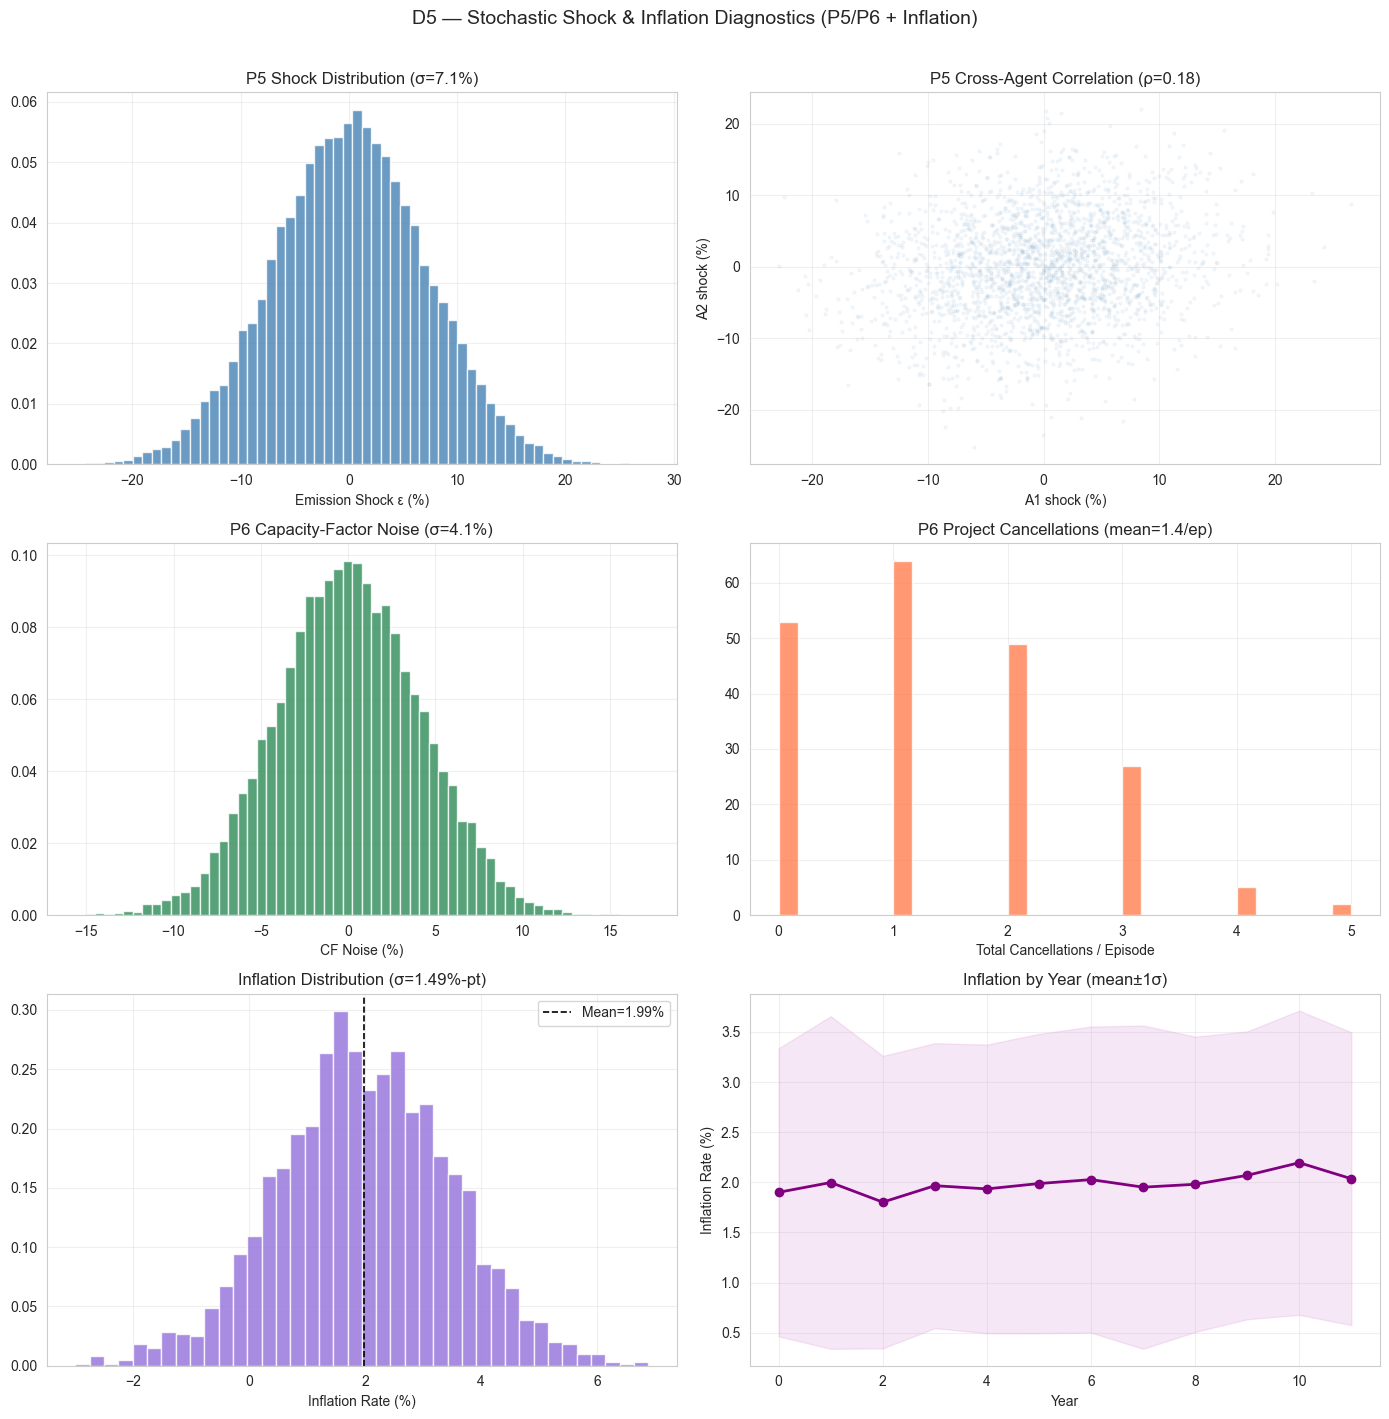

P5 emission shock active: True
P6 CF-noise active:       True
P6 cancellation active:   True
Inflation logged:         True
Inflation mean:           1.988%
Inflation std:            1.494%-pt


In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(14, 14))

shock_cols = [f'emission_shock_A{i+1}' for i in range(n_agents)]
cf_cols = [f'cf_shock_A{i+1}' for i in range(n_agents)]
cancel_cols = [f'cancellation_A{i+1}' for i in range(n_agents)]

has_shocks = any(c in recent_yr.columns for c in shock_cols) and recent_yr[shock_cols[0]].std() > 1e-6

# 1 — P5 shock distribution
ax = axes[0, 0]
if has_shocks:
    all_shocks = pd.concat([recent_yr[c] * 100 for c in shock_cols if c in recent_yr.columns])
    ax.hist(all_shocks, bins=60, color='steelblue', edgecolor='white', alpha=0.8, density=True)
    ax.set_xlabel('Emission Shock ε (%)')
    ax.set_title(f'P5 Shock Distribution (σ={all_shocks.std():.1f}%)')
else:
    ax.text(0.5, 0.5, 'P5 shocks inactive', ha='center', va='center', transform=ax.transAxes)
    ax.set_title('P5 — Inactive')
ax.grid(True, alpha=0.3)

# 2 — P5 cross-agent correlation
ax = axes[0, 1]
if has_shocks and n_agents >= 2:
    s1 = recent_yr[shock_cols[0]] * 100
    s2 = recent_yr[shock_cols[1]] * 100
    ax.scatter(s1, s2, alpha=0.05, s=5, color='steelblue')
    corr = s1.corr(s2)
    ax.set_xlabel('A1 shock (%)'); ax.set_ylabel('A2 shock (%)')
    ax.set_title(f'P5 Cross-Agent Correlation (ρ={corr:.2f})')
else:
    ax.text(0.5, 0.5, 'P5 inactive or <2 agents', ha='center', va='center', transform=ax.transAxes)
ax.grid(True, alpha=0.3)

# 3 — P6 CF noise
ax = axes[1, 0]
has_cf = any(c in recent_yr.columns for c in cf_cols) and recent_yr[cf_cols[0]].std() > 1e-8
if has_cf:
    all_cf = pd.concat([recent_yr[c] * 100 for c in cf_cols if c in recent_yr.columns])
    ax.hist(all_cf, bins=60, color='seagreen', edgecolor='white', alpha=0.8, density=True)
    ax.set_xlabel('CF Noise (%)')
    ax.set_title(f'P6 Capacity-Factor Noise (σ={all_cf.std():.1f}%)')
else:
    ax.text(0.5, 0.5, 'P6 CF-noise inactive', ha='center', va='center', transform=ax.transAxes)
    ax.set_title('P6 CF — Inactive')
ax.grid(True, alpha=0.3)

# 4 — P6 cancellations
ax = axes[1, 1]
has_cancel = any(c in recent_yr.columns for c in cancel_cols) and recent_yr[cancel_cols[0]].sum() > 0
if has_cancel:
    cancel_per_ep = recent_yr.groupby('episode')[cancel_cols].sum().sum(axis=1)
    ax.hist(cancel_per_ep, bins=30, color='coral', edgecolor='white', alpha=0.8)
    ax.set_xlabel('Total Cancellations / Episode')
    ax.set_title(f'P6 Project Cancellations (mean={cancel_per_ep.mean():.1f}/ep)')
else:
    ax.text(0.5, 0.5, 'P6 cancellations inactive', ha='center', va='center', transform=ax.transAxes)
    ax.set_title('P6 Cancellations — Inactive')
ax.grid(True, alpha=0.3)

# 5 — Inflation rate distribution
ax = axes[2, 0]
has_infl = 'inflation_rate' in recent_yr.columns and recent_yr['inflation_rate'].notna().any()
if has_infl:
    infl_pct = recent_yr['inflation_rate'] * 100
    ax.hist(infl_pct, bins=40, color='mediumpurple', edgecolor='white', alpha=0.8, density=True)
    ax.axvline(infl_pct.mean(), color='black', ls='--', lw=1.2, label=f'Mean={infl_pct.mean():.2f}%')
    ax.set_xlabel('Inflation Rate (%)')
    ax.set_title(f'Inflation Distribution (σ={infl_pct.std():.2f}%-pt)')
    ax.legend()
else:
    ax.text(0.5, 0.5, 'Inflation not logged in year_log', ha='center', va='center', transform=ax.transAxes)
    ax.set_title('Inflation — Not Available')
ax.grid(True, alpha=0.3)

# 6 — Inflation profile by year
ax = axes[2, 1]
if has_infl:
    infl_by_year = recent_yr.groupby('year')['inflation_rate'].agg(['mean', 'std']) * 100
    ax.plot(infl_by_year.index, infl_by_year['mean'], color='purple', marker='o', lw=2)
    std_fill = infl_by_year['std'].fillna(0.0)
    ax.fill_between(
        infl_by_year.index,
        infl_by_year['mean'] - std_fill,
        infl_by_year['mean'] + std_fill,
        color='plum', alpha=0.25
    )
    ax.set_xlabel('Year')
    ax.set_ylabel('Inflation Rate (%)')
    ax.set_title('Inflation by Year (mean±1σ)')
else:
    ax.text(0.5, 0.5, 'Inflation not logged in year_log', ha='center', va='center', transform=ax.transAxes)
    ax.set_title('Inflation by Year — Not Available')
ax.grid(True, alpha=0.3)

plt.suptitle('D5 — Stochastic Shock & Inflation Diagnostics (P5/P6 + Inflation)', fontsize=14, y=1.01)
plt.tight_layout(); plt.show()

# Summary
print(f'P5 emission shock active: {has_shocks}')
print(f'P6 CF-noise active:       {has_cf}')
print(f'P6 cancellation active:   {has_cancel}')
print(f'Inflation logged:         {has_infl}')
if has_infl:
    infl_pct = recent_yr['inflation_rate'] * 100
    print(f'Inflation mean:           {infl_pct.mean():.3f}%')
    print(f'Inflation std:            {infl_pct.std():.3f}%-pt')

---
# Part II — Strategy Deep Dive (A)

> *What strategies did the agents learn and why?*
>
> Drops the bot-comparison section (A7 / A7a) and the standalone summary / troubleshooting digest. The standalone collateral panel (A5b) is removed; collateral is folded into the cost-breakdown panel of §A5.

### A1. Auction Bidding Strategy

How agents bid in the primary EUA auction:
- **Price discovery** — do bids converge to a common clearing price?
- **Quantity strategy** — do agents bid for what they need or over/under-bid?
- **Archetype differences** — do coal-heavy agents bid differently from near-green?

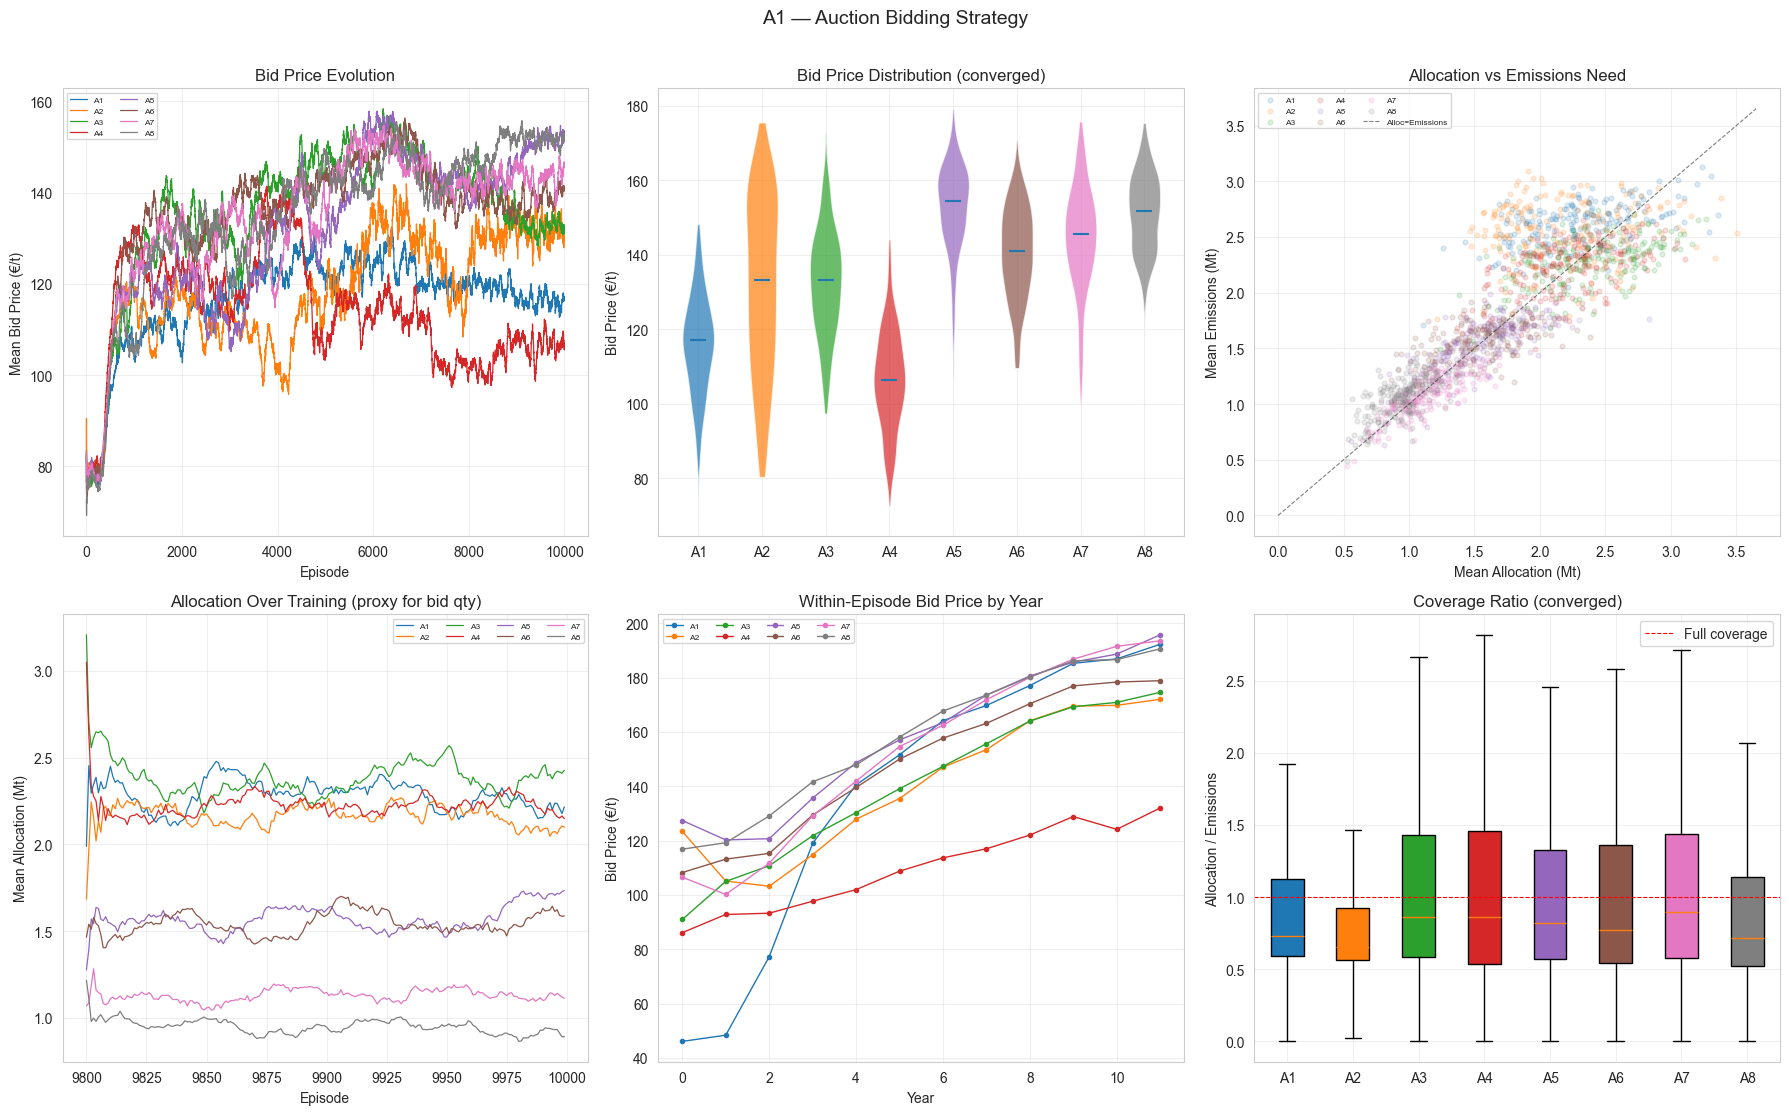

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))

# 1 — Bid price evolution per agent
ax = axes[0, 0]
for i in range(n_agents):
    ax.plot(ep_df['episode'], ep_df[f'bid_price_A{i+1}'].rolling(ROLL, min_periods=1).mean(),
            color=agent_colors[i], lw=0.9, label=agent_labels[i])
ax.set_xlabel('Episode'); ax.set_ylabel('Mean Bid Price (\u20ac/t)')
ax.set_title('Bid Price Evolution'); ax.legend(fontsize=6, ncol=2); ax.grid(True, alpha=0.3)

# 2 — Bid price distribution (converged)
ax = axes[0, 1]
bid_data = [recent_ep[f'bid_price_A{i+1}'].values for i in range(n_agents)]
parts = ax.violinplot(bid_data, positions=range(n_agents), showmedians=True, showextrema=False)
for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(agent_colors[i]); pc.set_alpha(0.7)
ax.set_xticks(range(n_agents)); ax.set_xticklabels([f'A{i+1}' for i in range(n_agents)])
ax.set_ylabel('Bid Price (\u20ac/t)')
ax.set_title('Bid Price Distribution (converged)'); ax.grid(True, alpha=0.3)

# 3 — Allocation vs Emissions scatter (converged)
ax = axes[0, 2]
for i in range(n_agents):
    allocs = recent_yr.groupby('episode')[f'alloc_A{i+1}'].mean()
    emiss = recent_yr.groupby('episode')[f'emissions_A{i+1}'].mean()
    ax.scatter(allocs, emiss, alpha=0.15, s=12, color=agent_colors[i], label=f'A{i+1}')
lims = [0, max(ax.get_xlim()[1], ax.get_ylim()[1])]
ax.plot(lims, lims, 'k--', lw=0.8, alpha=0.5, label='Alloc=Emissions')
ax.set_xlabel('Mean Allocation (Mt)'); ax.set_ylabel('Mean Emissions (Mt)')
ax.set_title('Allocation vs Emissions Need')
ax.legend(fontsize=6, ncol=3); ax.grid(True, alpha=0.3)

# 4 — Bid quantity evolution
ax = axes[1, 0]
for i in range(n_agents):
    alloc_roll = recent_yr.groupby('episode')[f'alloc_A{i+1}'].mean()
    alloc_smooth = alloc_roll.rolling(ROLL // 2, min_periods=1).mean()
    ax.plot(alloc_smooth.index, alloc_smooth.values, color=agent_colors[i], lw=0.9, label=f'A{i+1}')
ax.set_xlabel('Episode'); ax.set_ylabel('Mean Allocation (Mt)')
ax.set_title('Allocation Over Training (proxy for bid qty)'); ax.legend(fontsize=6, ncol=4)
ax.grid(True, alpha=0.3)

# 5 — Bid price by year within episode (converged)
ax = axes[1, 1]
for i in range(n_agents):
    bid_yr = recent_yr.groupby('year')[f'bid_price_A{i+1}'].mean()
    ax.plot(bid_yr.index, bid_yr.values, color=agent_colors[i], marker='o', ms=3,
            lw=1, label=f'A{i+1}')
ax.set_xlabel('Year'); ax.set_ylabel('Bid Price (\u20ac/t)')
ax.set_title('Within-Episode Bid Price by Year')
ax.legend(fontsize=6, ncol=4); ax.grid(True, alpha=0.3)

# 6 — Coverage ratio: allocation / emissions
ax = axes[1, 2]
cov_data = []
for i in range(n_agents):
    a = recent_yr[f'alloc_A{i+1}']
    e = recent_yr[f'emissions_A{i+1}'].replace(0, np.nan)
    cov_data.append((a / e).dropna().values)
bp = ax.boxplot(cov_data, tick_labels=[f'A{i+1}' for i in range(n_agents)],
                patch_artist=True, showfliers=False)
for i, patch in enumerate(bp['boxes']):
    patch.set_facecolor(agent_colors[i])
ax.axhline(1.0, color='red', ls='--', lw=0.8, label='Full coverage')
ax.set_ylabel('Allocation / Emissions')
ax.set_title('Coverage Ratio (converged)'); ax.legend(); ax.grid(True, alpha=0.3)

plt.suptitle('A1 \u2014 Auction Bidding Strategy', fontsize=14, y=1.01)
plt.tight_layout(); plt.show()

### A2. Secondary Market Strategy

How agents trade on the secondary market:
- **Role evolution** — who becomes a net buyer vs seller over training?
- **Year-by-year patterns** — do roles shift within an episode as the cap tightens?
- **Price premiums** — secondary vs auction price spread
- **Cost/revenue** — who profits from secondary trading?

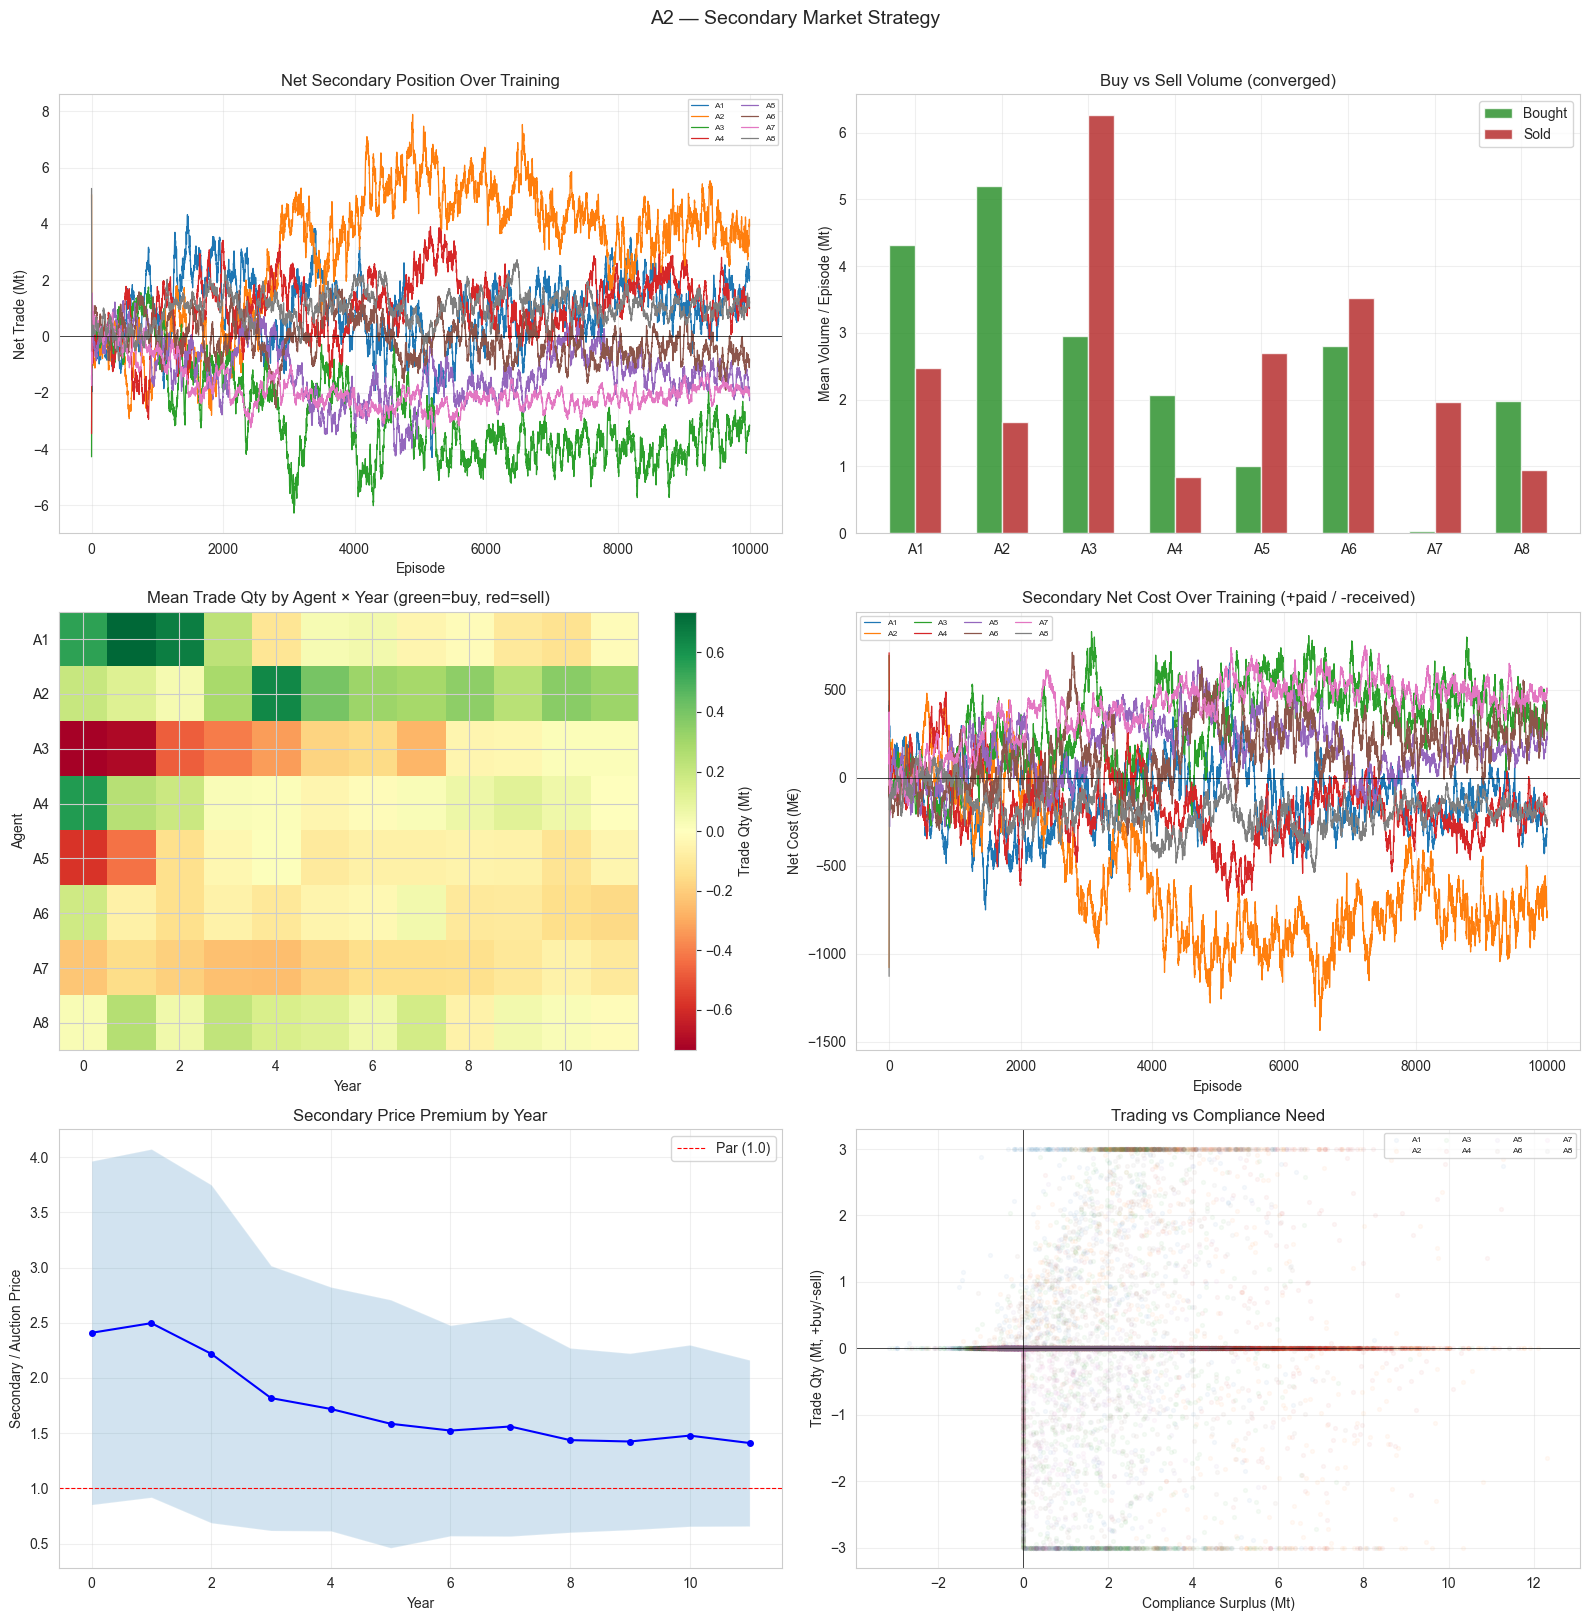

In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(16, 16))

# 1 — Net trade position over training (rolling)
ax = axes[0, 0]
for i in range(n_agents):
    net_trade = yr_df.groupby('episode')[f'trade_qty_A{i+1}'].sum()
    ax.plot(net_trade.index, net_trade.rolling(ROLL, min_periods=1).mean(),
            color=agent_colors[i], lw=0.9, label=agent_labels[i])
ax.axhline(0, color='black', ls='-', lw=0.5)
ax.set_xlabel('Episode'); ax.set_ylabel('Net Trade (Mt)')
ax.set_title('Net Secondary Position Over Training')
ax.legend(fontsize=6, ncol=2); ax.grid(True, alpha=0.3)

# 2 — Buy vs Sell volume per agent (converged)
ax = axes[0, 1]
buy_vols = []
sell_vols = []
for i in range(n_agents):
    tq = recent_yr[f'trade_qty_A{i+1}']
    buy_vols.append(tq[tq > 0.01].sum() / LAST_N)
    sell_vols.append(abs(tq[tq < -0.01].sum()) / LAST_N)
x = np.arange(n_agents)
ax.bar(x - 0.15, buy_vols, 0.3, color='forestgreen', alpha=0.8, label='Bought')
ax.bar(x + 0.15, sell_vols, 0.3, color='firebrick', alpha=0.8, label='Sold')
ax.set_xticks(x); ax.set_xticklabels([f'A{i+1}' for i in range(n_agents)])
ax.set_ylabel('Mean Volume / Episode (Mt)')
ax.set_title('Buy vs Sell Volume (converged)'); ax.legend(); ax.grid(True, alpha=0.3)

# 3 — Trade position by year within episode (heatmap)
ax = axes[1, 0]
trade_matrix = np.zeros((n_agents, n_years_per_ep))
for i in range(n_agents):
    trade_by_yr = recent_yr.groupby('year')[f'trade_qty_A{i+1}'].mean()
    trade_matrix[i, :len(trade_by_yr)] = trade_by_yr.values
vmax = max(abs(trade_matrix.min()), abs(trade_matrix.max()))
im = ax.imshow(trade_matrix, aspect='auto', cmap='RdYlGn', vmin=-vmax, vmax=vmax)
ax.set_xlabel('Year'); ax.set_ylabel('Agent')
ax.set_yticks(range(n_agents)); ax.set_yticklabels([f'A{i+1}' for i in range(n_agents)])
ax.set_title('Mean Trade Qty by Agent \u00d7 Year (green=buy, red=sell)')
plt.colorbar(im, ax=ax, label='Trade Qty (Mt)')

# 4 — Net secondary cost over training
ax = axes[1, 1]
for i in range(n_agents):
    snet = yr_df.groupby('episode')[f'secondary_net_A{i+1}'].sum()
    ax.plot(snet.index, snet.rolling(ROLL, min_periods=1).mean(),
            color=agent_colors[i], lw=0.9, label=f'A{i+1}')
ax.axhline(0, color='black', ls='-', lw=0.5)
ax.set_xlabel('Episode'); ax.set_ylabel('Net Cost (M\u20ac)')
ax.set_title('Secondary Net Cost Over Training (+paid / -received)')
ax.legend(fontsize=6, ncol=4); ax.grid(True, alpha=0.3)

# 5 — Secondary price premium over auction
ax = axes[2, 0]
premium = recent_yr['secondary_price'] / recent_yr['clearing_price'].replace(0, np.nan)
premium_yr = premium.groupby(recent_yr['year']).agg(['mean', 'std'])
ax.plot(premium_yr.index, premium_yr['mean'], 'b-o', ms=4, lw=1.5)
ax.fill_between(premium_yr.index,
                premium_yr['mean'] - premium_yr['std'],
                premium_yr['mean'] + premium_yr['std'], alpha=0.2)
ax.axhline(1.0, color='red', ls='--', lw=0.8, label='Par (1.0)')
ax.set_xlabel('Year'); ax.set_ylabel('Secondary / Auction Price')
ax.set_title('Secondary Price Premium by Year'); ax.legend(); ax.grid(True, alpha=0.3)

# 6 — Trade qty vs compliance surplus (who trades based on need?)
ax = axes[2, 1]
if 'compliance_surplus_A1' in recent_yr.columns:
    for i in range(n_agents):
        ax.scatter(recent_yr[f'compliance_surplus_A{i+1}'],
                   recent_yr[f'trade_qty_A{i+1}'],
                   alpha=0.04, s=8, color=agent_colors[i], label=f'A{i+1}')
    ax.axhline(0, color='black', ls='-', lw=0.5)
    ax.axvline(0, color='black', ls='-', lw=0.5)
    ax.set_xlabel('Compliance Surplus (Mt)')
    ax.set_ylabel('Trade Qty (Mt, +buy/-sell)')
    ax.set_title('Trading vs Compliance Need')
    ax.legend(fontsize=6, ncol=4)
else:
    ax.text(0.5, 0.5, 'compliance_surplus not logged', ha='center', va='center',
            transform=ax.transAxes)
ax.grid(True, alpha=0.3)

plt.suptitle('A2 \u2014 Secondary Market Strategy', fontsize=14, y=1.01)
plt.tight_layout(); plt.show()

### A3. Green Transition Strategy

Investment patterns in renewable energy:
- **Transition speed** — how quickly does each archetype green its portfolio?
- **Investment intensity** — how aggressively do agents invest?
- **Technology preference** — onshore wind, offshore wind, or solar?
- **Construction pipeline** — queuing effects and timing

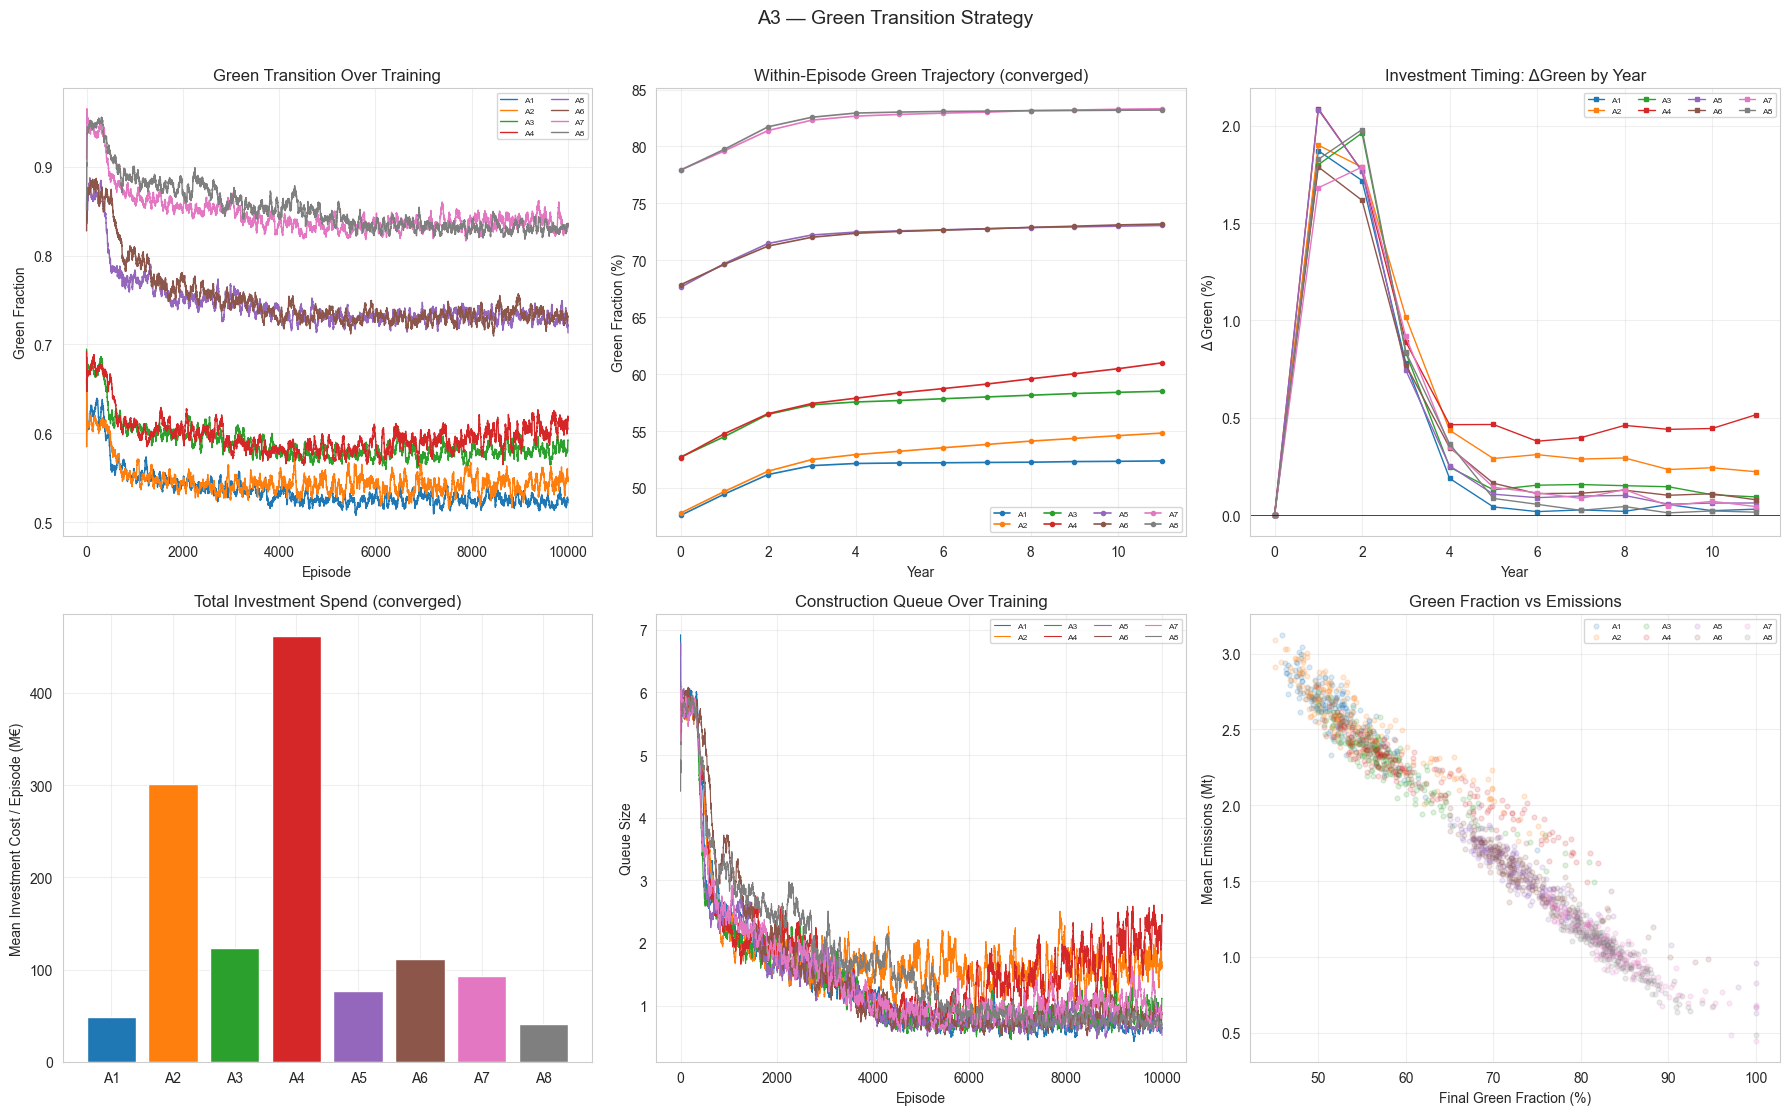

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))

# 1 — Green fraction evolution over training
ax = axes[0, 0]
for i in range(n_agents):
    ax.plot(ep_df['episode'], ep_df[f'green_frac_A{i+1}'].rolling(ROLL, min_periods=1).mean(),
            color=agent_colors[i], lw=1, label=agent_labels[i])
ax.set_xlabel('Episode'); ax.set_ylabel('Green Fraction')
ax.set_title('Green Transition Over Training')
ax.legend(fontsize=6, ncol=2); ax.grid(True, alpha=0.3)

# 2 — Green fraction by year within episode (converged)
ax = axes[0, 1]
for i in range(n_agents):
    gf_yr = recent_yr.groupby('year')[f'green_frac_A{i+1}'].mean()
    ax.plot(gf_yr.index, gf_yr.values * 100, color=agent_colors[i], marker='o', ms=3,
            lw=1.2, label=f'A{i+1}')
ax.set_xlabel('Year'); ax.set_ylabel('Green Fraction (%)')
ax.set_title('Within-Episode Green Trajectory (converged)')
ax.legend(fontsize=6, ncol=4); ax.grid(True, alpha=0.3)

# 3 — Delta green by year (when do agents invest?)
ax = axes[0, 2]
for i in range(n_agents):
    dg_yr = recent_yr.groupby('year')[f'delta_green_A{i+1}'].mean() * 100
    ax.plot(dg_yr.index, dg_yr.values, color=agent_colors[i], marker='s', ms=3,
            lw=1, label=f'A{i+1}')
ax.axhline(0, color='black', ls='-', lw=0.5)
ax.set_xlabel('Year'); ax.set_ylabel('\u0394 Green (%)')
ax.set_title('Investment Timing: \u0394Green by Year')
ax.legend(fontsize=6, ncol=4); ax.grid(True, alpha=0.3)

# 4 — Investment cost per agent (converged)
ax = axes[1, 0]
inv_means = [recent_yr.groupby('episode')[f'invest_cost_A{i+1}'].sum().mean()
             for i in range(n_agents)]
ax.bar([f'A{i+1}' for i in range(n_agents)], inv_means, color=agent_colors)
ax.set_ylabel('Mean Investment Cost / Episode (M\u20ac)')
ax.set_title('Total Investment Spend (converged)'); ax.grid(True, alpha=0.3)

# 5 — Construction queue over training
ax = axes[1, 1]
for i in range(n_agents):
    col = f'queue_size_A{i+1}'
    if col in ep_df.columns:
        ax.plot(ep_df['episode'], ep_df[col].rolling(ROLL, min_periods=1).mean(),
                color=agent_colors[i], lw=0.8, label=f'A{i+1}')
ax.set_xlabel('Episode'); ax.set_ylabel('Queue Size')
ax.set_title('Construction Queue Over Training')
ax.legend(fontsize=6, ncol=4); ax.grid(True, alpha=0.3)

# 6 — Green fraction vs emissions (converged)
ax = axes[1, 2]
for i in range(n_agents):
    gf = recent_yr.groupby('episode')[f'green_frac_A{i+1}'].last()
    em = recent_yr.groupby('episode')[f'emissions_A{i+1}'].mean()
    ax.scatter(gf * 100, em, alpha=0.15, s=12, color=agent_colors[i], label=f'A{i+1}')
ax.set_xlabel('Final Green Fraction (%)'); ax.set_ylabel('Mean Emissions (Mt)')
ax.set_title('Green Fraction vs Emissions')
ax.legend(fontsize=6, ncol=4); ax.grid(True, alpha=0.3)

plt.suptitle('A3 \u2014 Green Transition Strategy', fontsize=14, y=1.01)
plt.tight_layout(); plt.show()

### A4. Compliance & Banking Strategy

How agents manage their allowance portfolio:
- **Banking** — accumulating surplus for future compliance
- **Shortfall avoidance** — learning to stay compliant
- **Risk management** — holdings buffer vs cost minimization

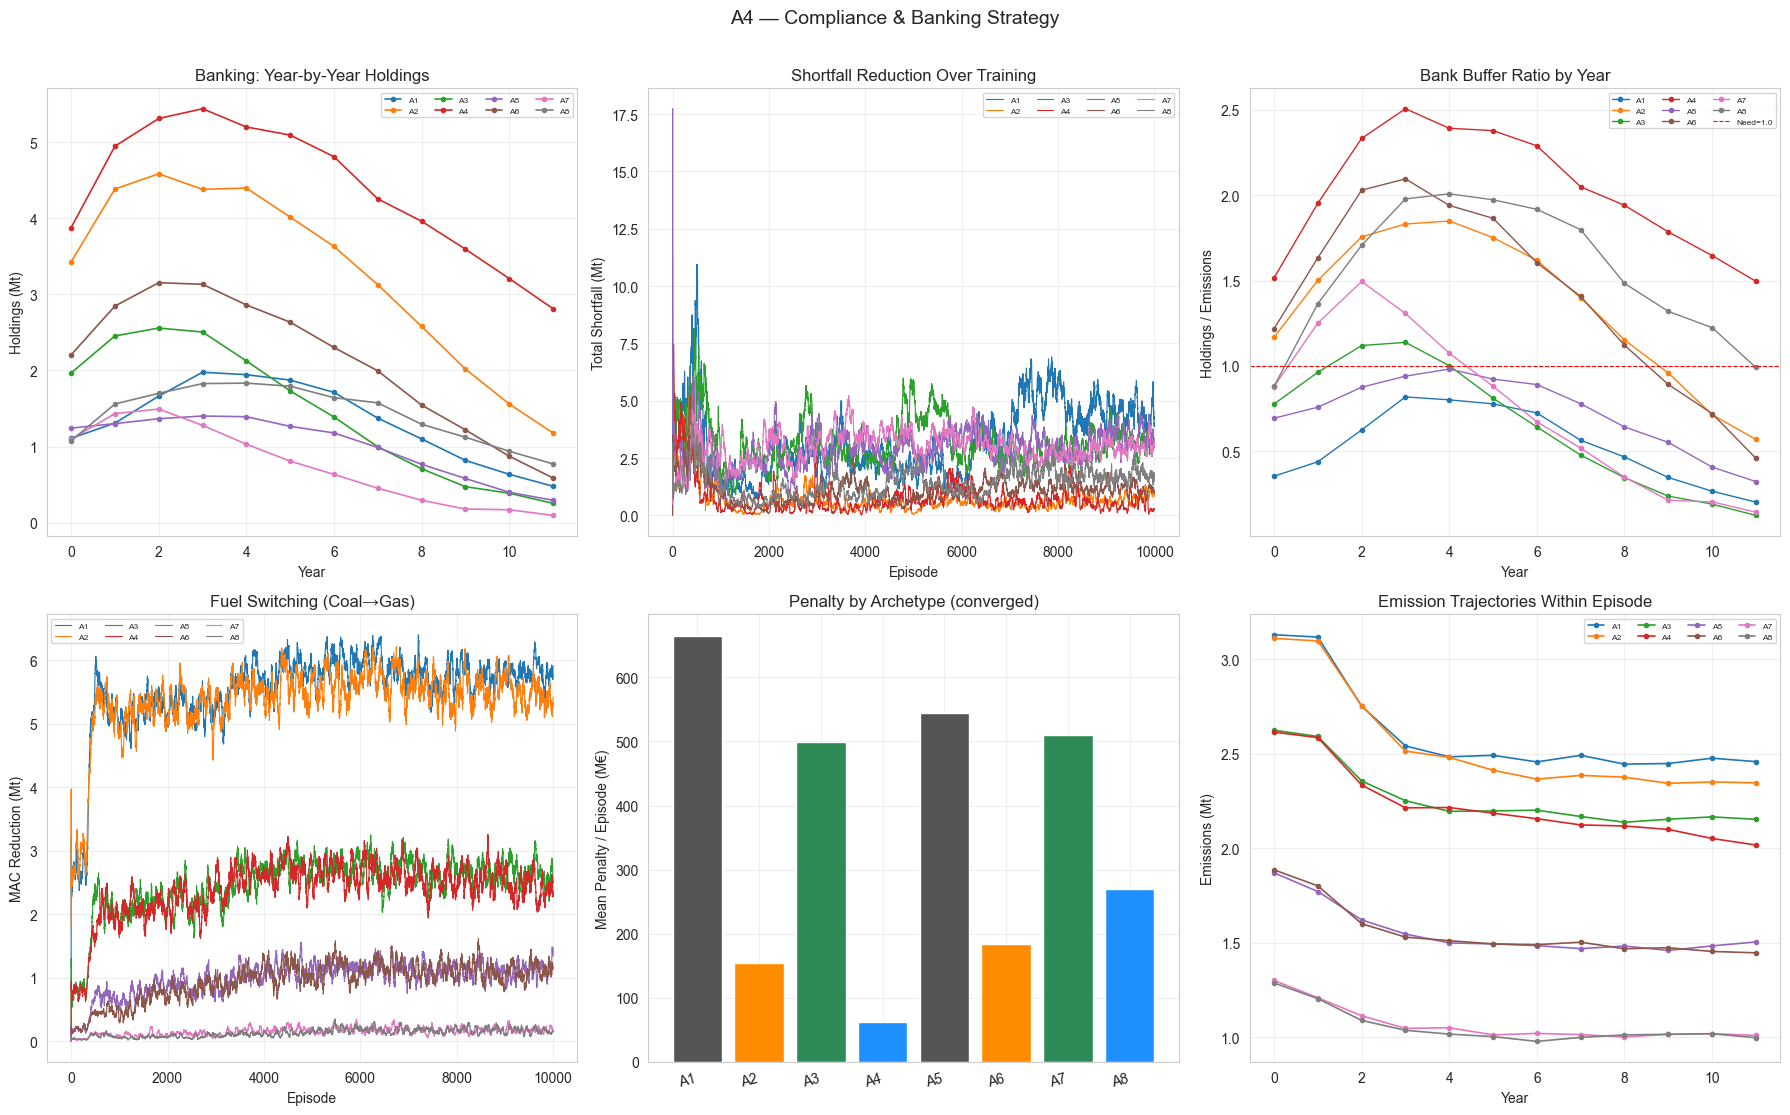

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))

# 1 — Holdings trajectory by year (converged)
ax = axes[0, 0]
for i in range(n_agents):
    h_yr = recent_yr.groupby('year')[f'holdings_A{i+1}'].mean()
    ax.plot(h_yr.index, h_yr.values, color=agent_colors[i], marker='o', ms=3,
            lw=1.2, label=f'A{i+1}')
ax.set_xlabel('Year'); ax.set_ylabel('Holdings (Mt)')
ax.set_title('Banking: Year-by-Year Holdings')
ax.legend(fontsize=6, ncol=4); ax.grid(True, alpha=0.3)

# 2 — Shortfall per agent over training
ax = axes[0, 1]
for i in range(n_agents):
    sf = ep_df[f'shortfall_A{i+1}'].rolling(ROLL, min_periods=1).mean()
    ax.plot(ep_df['episode'], sf, color=agent_colors[i], lw=0.8, label=f'A{i+1}')
ax.set_xlabel('Episode'); ax.set_ylabel('Total Shortfall (Mt)')
ax.set_title('Shortfall Reduction Over Training')
ax.legend(fontsize=6, ncol=4); ax.grid(True, alpha=0.3)

# 3 — Holdings vs emissions need (buffer ratio)
ax = axes[0, 2]
for i in range(n_agents):
    h = recent_yr[f'holdings_A{i+1}']
    e = recent_yr[f'emissions_A{i+1}'].replace(0, np.nan)
    buffer = (h / e).dropna()
    buf_yr = buffer.groupby(recent_yr.loc[buffer.index, 'year']).mean()
    ax.plot(buf_yr.index, buf_yr.values, color=agent_colors[i], marker='o', ms=3,
            lw=1, label=f'A{i+1}')
ax.axhline(1.0, color='red', ls='--', lw=0.8, label='Need=1.0')
ax.set_xlabel('Year'); ax.set_ylabel('Holdings / Emissions')
ax.set_title('Bank Buffer Ratio by Year')
ax.legend(fontsize=6, ncol=3); ax.grid(True, alpha=0.3)

# 4 — MAC fuel-switching usage
ax = axes[1, 0]
mac_cols_ep = [f'total_mac_reduction_A{i+1}' for i in range(n_agents)
               if f'total_mac_reduction_A{i+1}' in ep_df.columns]
if mac_cols_ep:
    for i, col in enumerate(mac_cols_ep):
        ax.plot(ep_df['episode'], ep_df[col].rolling(ROLL, min_periods=1).mean(),
                color=agent_colors[i], lw=0.8, label=f'A{i+1}')
    ax.set_xlabel('Episode'); ax.set_ylabel('MAC Reduction (Mt)')
    ax.set_title('Fuel Switching (Coal\u2192Gas)')
    ax.legend(fontsize=6, ncol=4)
else:
    ax.text(0.5, 0.5, 'MAC data not available', ha='center', va='center',
            transform=ax.transAxes)
ax.grid(True, alpha=0.3)

# 5 — Penalty by archetype
ax = axes[1, 1]
pen_by_arch = {}
for i in range(n_agents):
    arch = agent_labels[i].split('(')[1].rstrip(')') if '(' in agent_labels[i] else f'A{i+1}'
    pen = recent_ep[f'penalty_A{i+1}'].mean()
    pen_by_arch.setdefault(arch, []).append(pen)
arch_names = list(pen_by_arch.keys())
arch_means = [np.mean(v) for v in pen_by_arch.values()]
ax.bar(arch_names, arch_means, color=['#555555', '#FF8C00', '#2E8B57', '#1E90FF'][:len(arch_names)])
ax.set_ylabel('Mean Penalty / Episode (M\u20ac)')
ax.set_title('Penalty by Archetype (converged)')
plt.setp(ax.get_xticklabels(), rotation=15, ha='right')
ax.grid(True, alpha=0.3)

# 6 — Emissions trajectory by year (converged)
ax = axes[1, 2]
for i in range(n_agents):
    em_yr = recent_yr.groupby('year')[f'emissions_A{i+1}'].mean()
    ax.plot(em_yr.index, em_yr.values, color=agent_colors[i], marker='o', ms=3,
            lw=1.2, label=f'A{i+1}')
ax.set_xlabel('Year'); ax.set_ylabel('Emissions (Mt)')
ax.set_title('Emission Trajectories Within Episode')
ax.legend(fontsize=6, ncol=4); ax.grid(True, alpha=0.3)

plt.suptitle('A4 \u2014 Compliance & Banking Strategy', fontsize=14, y=1.01)
plt.tight_layout(); plt.show()

### A5. Reward Decomposition & Cost Structure

What drives agent rewards? Decompose into cost components to understand
the economic trade-offs agents face.

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))

# 1 — Reward distribution (converged)
ax = axes[0, 0]
rew_data = [recent_ep[f'reward_A{i+1}'].values for i in range(n_agents)]
bp = ax.boxplot(rew_data, tick_labels=[f'A{i+1}' for i in range(n_agents)],
                patch_artist=True, showfliers=False)
for i, patch in enumerate(bp['boxes']):
    patch.set_facecolor(agent_colors[i])
ax.set_ylabel('Total Reward / Episode')
ax.set_title('Reward Distribution (converged)'); ax.grid(True, alpha=0.3)

# 2 — Cost breakdown per agent (converged means)
ax = axes[0, 1]
cost_components = {}
for comp, col_tmpl in [('Auction',     'auction_cost_A{}'),
                       ('SecondaryNet','secondary_net_A{}'),
                       ('Investment',  'invest_cost_A{}'),
                       ('Penalty',     'penalty_A{}'),
                       ('Collateral',  'collateral_cost_A{}')]:
    means = []
    for i in range(n_agents):
        col = col_tmpl.format(i+1)
        if col in recent_yr.columns:
            means.append(recent_yr.groupby('episode')[col].sum().mean())
        else:
            means.append(0)
    cost_components[comp] = means

x = np.arange(n_agents)
bottom = np.zeros(n_agents)
comp_colors = {'Auction': 'steelblue', 'SecondaryNet': 'coral',
               'Investment': 'seagreen', 'Penalty': 'firebrick',
               'Collateral': 'goldenrod'}
for comp, vals in cost_components.items():
    vals_pos = np.maximum(vals, 0)
    ax.bar(x, vals_pos, 0.6, bottom=bottom, label=comp, color=comp_colors[comp], alpha=0.85)
    bottom += vals_pos
ax.set_xticks(x); ax.set_xticklabels([f'A{i+1}' for i in range(n_agents)])
ax.set_ylabel('Cost (M€ / episode)')
ax.set_title('Cost Breakdown by Agent'); ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

# 3 — Reward vs green fraction
ax = axes[0, 2]
for i in range(n_agents):
    gf = recent_ep[f'green_frac_A{i+1}']
    rw = recent_ep[f'reward_A{i+1}']
    ax.scatter(gf * 100, rw, alpha=0.15, s=12, color=agent_colors[i], label=f'A{i+1}')
ax.set_xlabel('Final Green Fraction (%)'); ax.set_ylabel('Total Reward')
ax.set_title('Reward vs Green Fraction')
ax.legend(fontsize=6, ncol=4); ax.grid(True, alpha=0.3)

# 4 — Reward by archetype over training
ax = axes[1, 0]
n_per_arch = n_agents // 4
for a_idx, arch in enumerate(_base_archetypes):
    agent_ids = list(range(a_idx * n_per_arch, (a_idx + 1) * n_per_arch))
    if not agent_ids:
        continue
    arch_rew = sum(ep_df[f'reward_A{i+1}'] for i in agent_ids) / len(agent_ids)
    ax.plot(ep_df['episode'], arch_rew.rolling(ROLL, min_periods=1).mean(),
            lw=1.5, label=arch)
ax.set_xlabel('Episode'); ax.set_ylabel('Mean Reward')
ax.set_title('Reward by Archetype'); ax.legend(); ax.grid(True, alpha=0.3)

# 5 — Cost by year within episode
ax = axes[1, 1]
if 'auction_cost_A1' in recent_yr.columns:
    for comp, col_tmpl, color in [('Auction', 'auction_cost_A{}', 'steelblue'),
                                   ('Investment', 'invest_cost_A{}', 'seagreen')]:
        total = sum(recent_yr[col_tmpl.format(i+1)] for i in range(n_agents))
        by_yr = total.groupby(recent_yr['year']).mean()
        ax.plot(by_yr.index, by_yr.values, marker='o', ms=4, lw=1.5, color=color, label=comp)
    ax.set_xlabel('Year'); ax.set_ylabel('Total Cost (M€)')
    ax.set_title('System Cost by Year'); ax.legend(); ax.grid(True, alpha=0.3)

# 6 — Reward per year within episode
ax = axes[1, 2]
for i in range(n_agents):
    rew_yr = recent_yr.groupby('year')[f'reward_A{i+1}'].mean()
    ax.plot(rew_yr.index, rew_yr.values, color=agent_colors[i], marker='o', ms=3,
            lw=1, label=f'A{i+1}')
ax.set_xlabel('Year'); ax.set_ylabel('Mean Reward')
ax.set_title('Reward by Year Within Episode')
ax.legend(fontsize=6, ncol=4); ax.grid(True, alpha=0.3)

plt.suptitle('A5 — Reward Decomposition & Cost Structure', fontsize=14, y=1.01)
plt.tight_layout(); plt.show()


### A6. Deterministic Evaluation of Best Agents

Load the best checkpoint and run a single deterministic episode to see
learned strategies without exploration noise.

In [ ]:
from scripts.train import build_agents

eval_env = ETSEnvironment(config, seed=0)
eval_agents = build_agents(eval_env, config, seed=0)
n_agents = config['companies']['n_agents']
tech_names = config['technologies']['names']

ckpt_dir = 'results/checkpoints_s42'
for i, agent in enumerate(eval_agents):
    ckpt_path = os.path.join(ckpt_dir, f'agent_{i}_best.pt')
    if os.path.exists(ckpt_path):
        agent.load(ckpt_path)
        print(f'Loaded agent {i}')
    else:
        print(f'No checkpoint for agent {i}')

obs1, _ = eval_env.reset(seed=0)
eval_data = []

for year in range(config['simulation']['n_years']):
    auction_actions = np.zeros((n_agents, 6), dtype=np.float32)
    for i in range(n_agents):
        action, _, _ = eval_agents[i].select_auction_action(obs1[i], deterministic=True)
        auction_actions[i] = action
    obs2, _ = eval_env.step_auction(auction_actions)

    secondary_actions = np.zeros((n_agents, 2), dtype=np.float32)
    for i in range(n_agents):
        action, _, _ = eval_agents[i].select_secondary_action(obs2[i], deterministic=True)
        secondary_actions[i] = action

    obs1, rewards, terminated, _, info = eval_env.step_secondary(secondary_actions)
    log = info['year_log']

    row = {'year': year, 'cap': log['cap'], 'price': log['clearing_price'],
           'secondary_price': log.get('secondary_clearing', 0), 'tnac': log.get('tnac', 0)}
    for i in range(n_agents):
        row[f'green_A{i+1}'] = log['green_fracs'][i]
        row[f'emissions_A{i+1}'] = log['emissions'][i]
        row[f'alloc_A{i+1}'] = log['allocations'][i]
        row[f'holdings_A{i+1}'] = log['holdings'][i]
        row[f'trade_qty_A{i+1}'] = log['trade_qtys'][i]
        row[f'trade_cost_A{i+1}'] = log['trade_costs'][i]
        row[f'shortfall_A{i+1}'] = log['shortfalls'][i]
        row[f'penalty_A{i+1}'] = log['penalties'][i]
        row[f'reward_A{i+1}'] = log['rewards'][i]
        row[f'invest_cost_A{i+1}'] = log['invest_costs'][i]
        for t in range(5):
            row[f'mix_A{i+1}_{tech_names[t]}'] = log['tech_mixes'][i][t]
    eval_data.append(row)
    if terminated:
        break

eval_df = pd.DataFrame(eval_data)
print(f'Evaluation: {len(eval_df)} years')
print(eval_df[['year', 'cap', 'price', 'tnac']].to_string(index=False))

Market calibration: 8 participants, emissions=20.7 Mt, cap=22.8 Mt
[ETSEnvironment] 8 learning + 0 bot = 8 total agents | cancel_under_subscribed=False


RuntimeError: Error(s) in loading state_dict for AuctionPolicy:
	size mismatch for layer_norm.weight: copying a param with shape torch.Size([87]) from checkpoint, the shape in current model is torch.Size([92]).
	size mismatch for layer_norm.bias: copying a param with shape torch.Size([87]) from checkpoint, the shape in current model is torch.Size([92]).
	size mismatch for fc1.weight: copying a param with shape torch.Size([256, 87]) from checkpoint, the shape in current model is torch.Size([256, 92]).

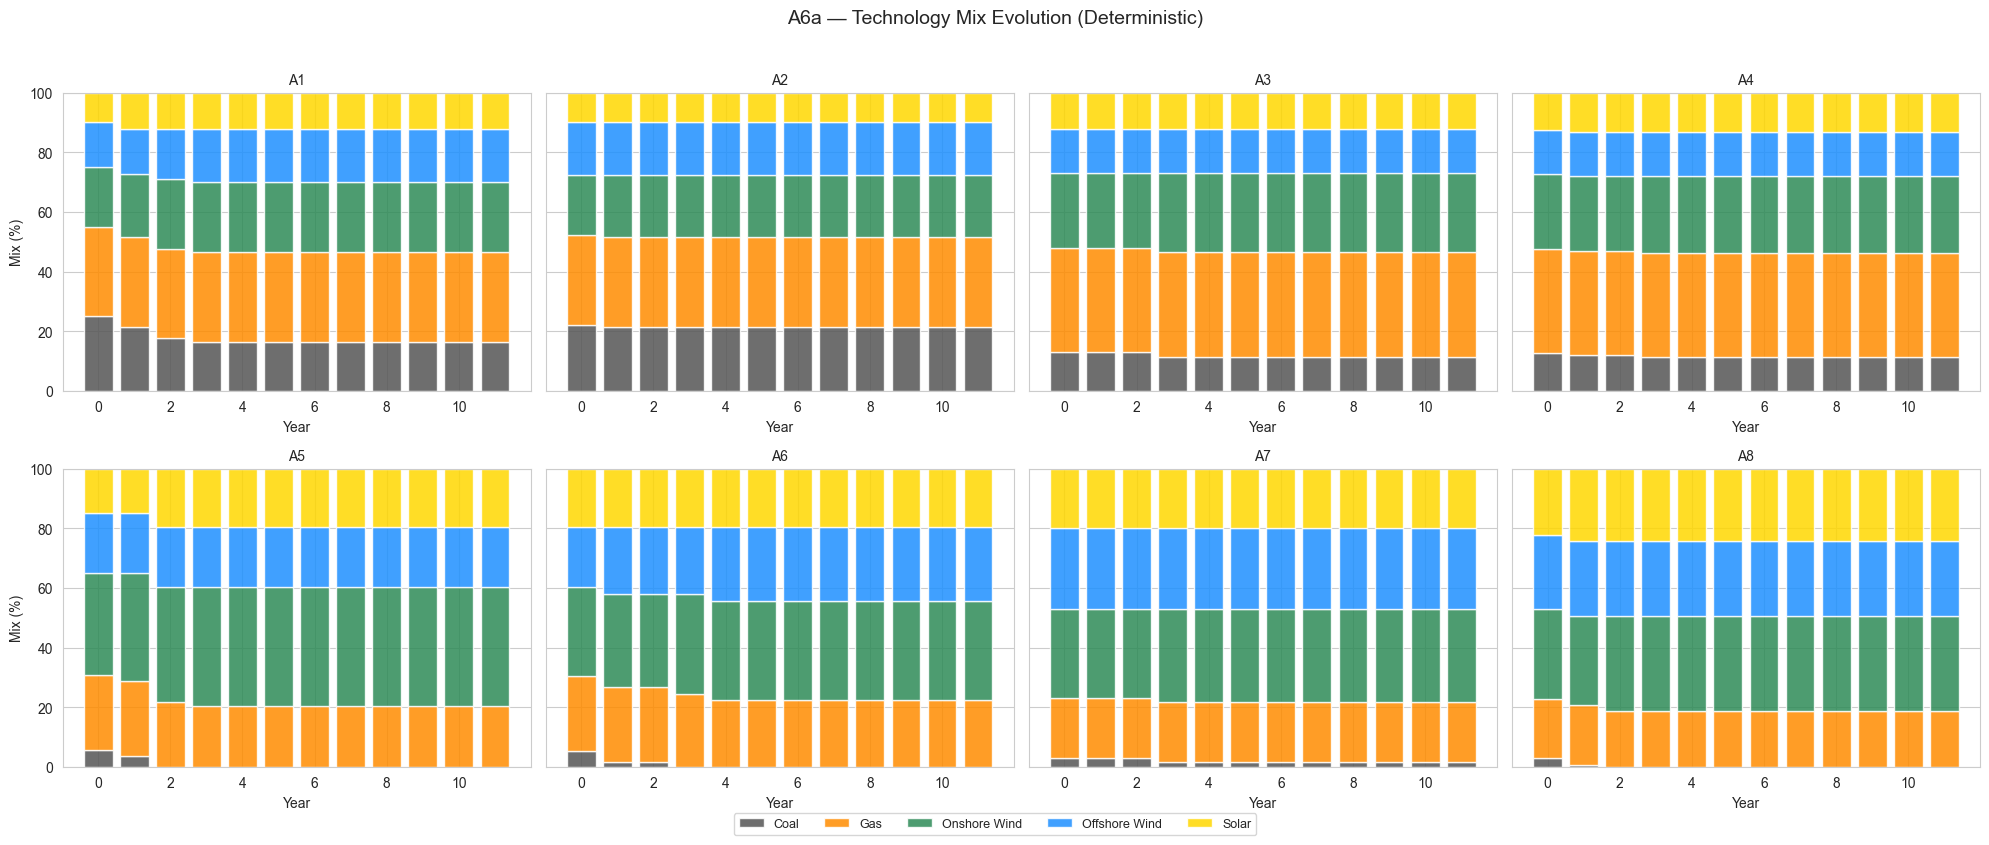

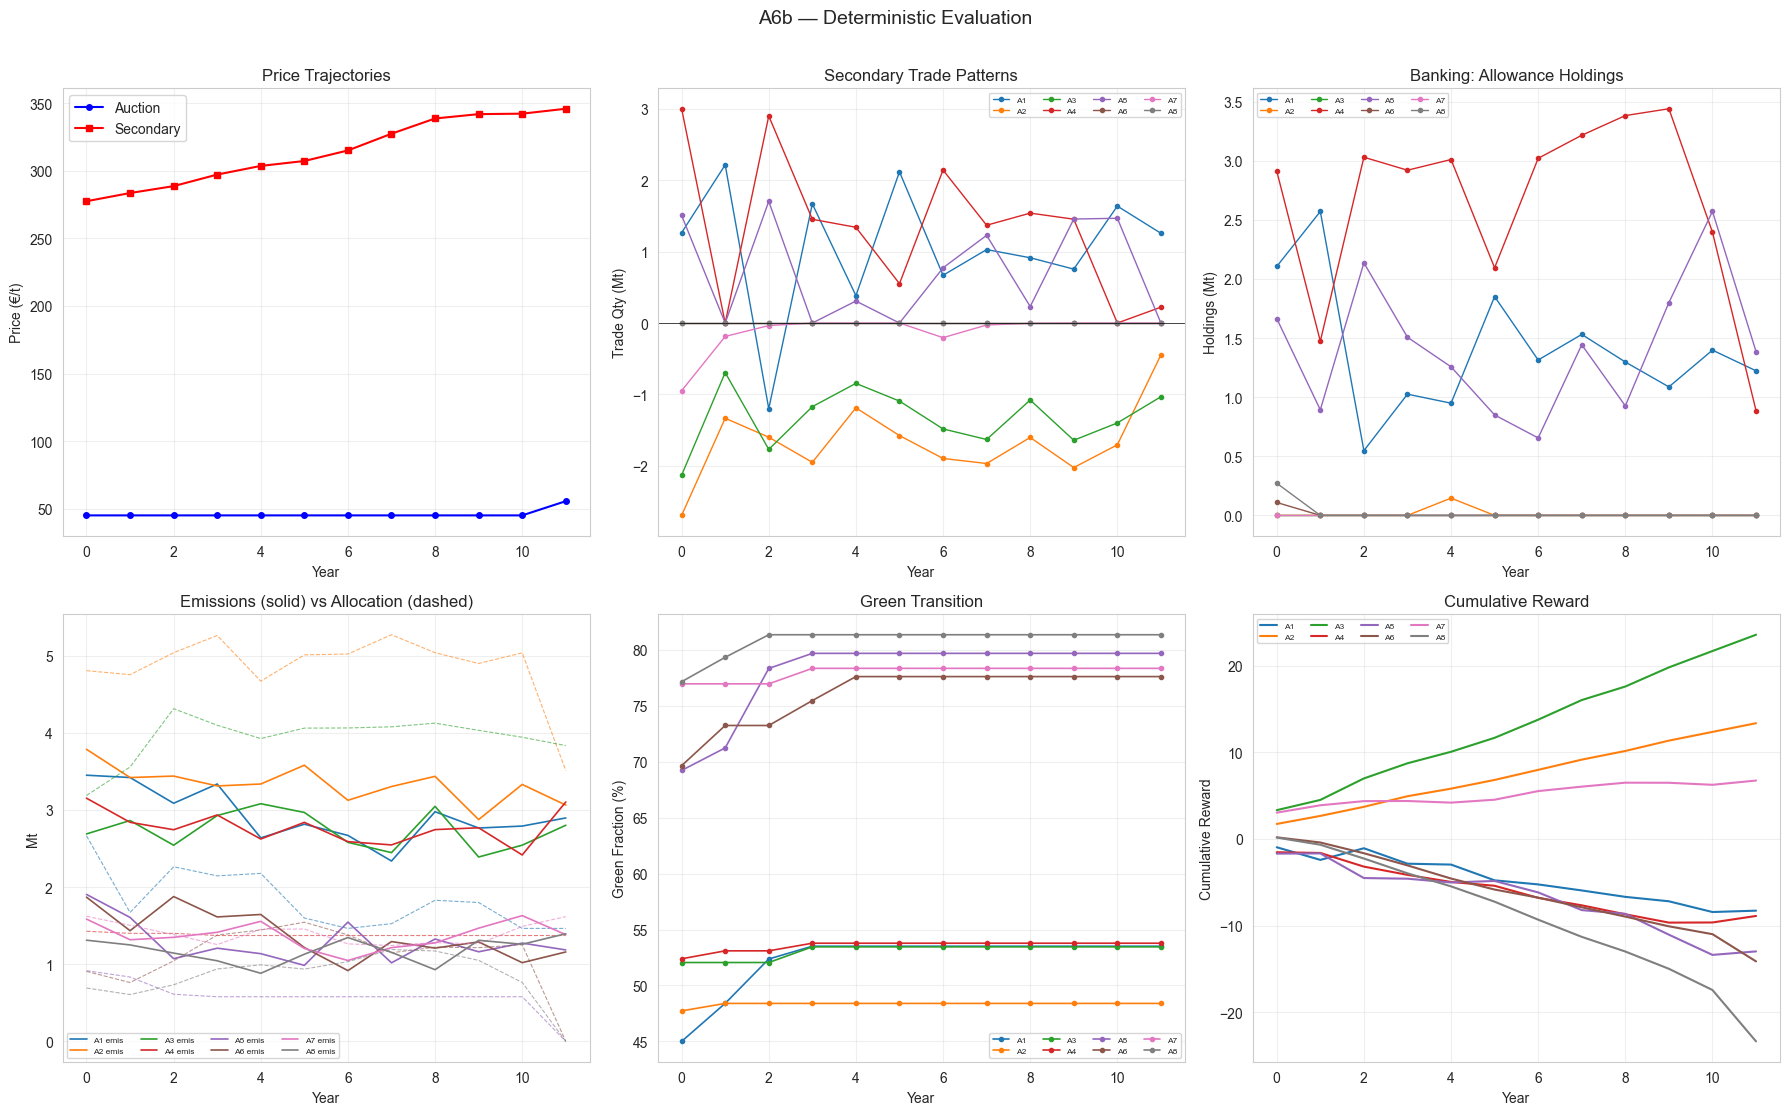

In [ ]:
# ── A6 Deterministic Evaluation Plots ─────────────────────────────────
tech_colors = {'coal': '#555555', 'gas': '#FF8C00', 'onshore_wind': '#2E8B57',
               'offshore_wind': '#1E90FF', 'solar': '#FFD700'}

# --- Tech mix: one subplot per agent ---
ncols = min(4, n_agents)
nrows_tech = (n_agents + ncols - 1) // ncols
fig_tech, axes_tech = plt.subplots(nrows_tech, ncols, figsize=(5*ncols, 4*nrows_tech), sharey=True)
axes_tech = np.atleast_1d(axes_tech).flatten()

for i in range(n_agents):
    ax = axes_tech[i]
    bottom_v = np.zeros(len(eval_df))
    for t in range(5):
        vals = eval_df[f'mix_A{i+1}_{tech_names[t]}'].values * 100
        ax.bar(eval_df['year'], vals, bottom=bottom_v,
               color=tech_colors[tech_names[t]], alpha=0.85,
               label=tech_names[t].replace('_', ' ').title())
        bottom_v += vals
    ax.set_title(f'{agent_labels[i]}', fontsize=10)
    ax.set_ylim(0, 100)
    if i % ncols == 0:
        ax.set_ylabel('Mix (%)')
    ax.set_xlabel('Year')

for j in range(n_agents, len(axes_tech)):
    axes_tech[j].set_visible(False)

handles, labels = axes_tech[0].get_legend_handles_labels()
fig_tech.legend(handles, labels, loc='lower center', ncol=5, fontsize=9, bbox_to_anchor=(0.5, -0.02))
fig_tech.suptitle('A6a — Technology Mix Evolution (Deterministic)', fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

# --- Key strategy plots ---
fig, axes = plt.subplots(2, 3, figsize=(18, 11))

# 1 — Prices
ax = axes[0, 0]
ax.plot(eval_df['year'], eval_df['price'], 'b-o', ms=4, label='Auction', lw=1.5)
ax.plot(eval_df['year'], eval_df['secondary_price'], 'r-s', ms=4, label='Secondary', lw=1.5)
ax.set_xlabel('Year'); ax.set_ylabel('Price (\u20ac/t)')
ax.set_title('Price Trajectories'); ax.legend(); ax.grid(True, alpha=0.3)

# 2 — Trade patterns
ax = axes[0, 1]
for i in range(n_agents):
    ax.plot(eval_df['year'], eval_df[f'trade_qty_A{i+1}'], color=agent_colors[i],
            marker='o', ms=3, lw=1, label=f'A{i+1}')
ax.axhline(0, color='black', ls='-', lw=0.5)
ax.set_xlabel('Year'); ax.set_ylabel('Trade Qty (Mt)')
ax.set_title('Secondary Trade Patterns')
ax.legend(fontsize=6, ncol=4); ax.grid(True, alpha=0.3)

# 3 — Holdings
ax = axes[0, 2]
for i in range(n_agents):
    ax.plot(eval_df['year'], eval_df[f'holdings_A{i+1}'], color=agent_colors[i],
            marker='o', ms=3, lw=1, label=f'A{i+1}')
ax.set_xlabel('Year'); ax.set_ylabel('Holdings (Mt)')
ax.set_title('Banking: Allowance Holdings')
ax.legend(fontsize=6, ncol=4); ax.grid(True, alpha=0.3)

# 4 — Emissions vs Allocations
ax = axes[1, 0]
for i in range(n_agents):
    ax.plot(eval_df['year'], eval_df[f'emissions_A{i+1}'], color=agent_colors[i],
            ls='-', lw=1.2, label=f'A{i+1} emis')
    ax.plot(eval_df['year'], eval_df[f'alloc_A{i+1}'], color=agent_colors[i],
            ls='--', lw=0.8, alpha=0.6)
ax.set_xlabel('Year'); ax.set_ylabel('Mt')
ax.set_title('Emissions (solid) vs Allocation (dashed)')
ax.legend(fontsize=6, ncol=4); ax.grid(True, alpha=0.3)

# 5 — Green fraction
ax = axes[1, 1]
for i in range(n_agents):
    ax.plot(eval_df['year'], eval_df[f'green_A{i+1}'] * 100, color=agent_colors[i],
            marker='o', ms=3, lw=1.2, label=f'A{i+1}')
ax.set_xlabel('Year'); ax.set_ylabel('Green Fraction (%)')
ax.set_title('Green Transition'); ax.legend(fontsize=6, ncol=4); ax.grid(True, alpha=0.3)

# 6 — Cumulative reward
ax = axes[1, 2]
for i in range(n_agents):
    cum_rew = eval_df[f'reward_A{i+1}'].cumsum()
    ax.plot(eval_df['year'], cum_rew, color=agent_colors[i], lw=1.5, label=f'A{i+1}')
ax.set_xlabel('Year'); ax.set_ylabel('Cumulative Reward')
ax.set_title('Cumulative Reward')
ax.legend(fontsize=6, ncol=4); ax.grid(True, alpha=0.3)

plt.suptitle('A6b — Deterministic Evaluation', fontsize=14, y=1.01)
plt.tight_layout(); plt.show()